# Transcript Intelligence — Take-Home Solution

**Author:** Palkesh
**Dataset:** 100 call transcripts across support / external / internal call types
**Stack:** Python · sentence-transformers · scikit-learn · VADER · matplotlib · (Anthropic SDK, optional)

This notebook is **the reference for the work** — the story is in the slide deck (`slides/`).
Every figure here is saved as a PNG in `outputs/figures/` and embedded in the deck. Every table
is saved in `outputs/tables/`. The full pipeline runs in ~30 seconds with `python -m src.run_pipeline`.

---

## How this notebook is organised

1. **Setup & ingestion** — what the data looks like, how we classify call type and customer.
2. **Task 1 — Topic categorisation** — embedding-based clustering and how we named the themes.
3. **Task 2 — Sentiment trends** — independent re-scoring, cross-call-type breakdown, what the
   numbers actually *mean*.
4. **Bonus 1 — Customer journey** (cross-call entity linking).
5. **Bonus 2 — Churn risk score** for external accounts.
6. **Bonus 3 — Speaker dynamics** (AM/agent talk-time, coaching signal).
7. **Additional ideas we didn't implement** — written-up insights for the panel discussion.

> Pipeline modules live in `src/`. The notebook calls them rather than inlining the code, so the
> implementation and the narrative stay separate.

In [12]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_rows", 60)

ROOT = Path.cwd()
FIG = ROOT / "outputs" / "figures"
TBL = ROOT / "outputs" / "tables"
DATA = ROOT / "data"



## 1. Setup & ingestion

### What's in the dataset?

Each transcript directory has six JSON files:

| file | what it gives us |
|------|------------------|
| `meeting-info.json` | title, organizer, attendees (emails), duration |
| `transcript.json` | sentence-level transcript with **per-sentence sentiment** (pre-labelled) |
| `summary.json` | LLM-generated summary, action items, topics, **overall sentiment label + score**, key moments |
| `speakers.json` | speaker turn timings |
| `events.json` | join/leave events |
| `speaker-meta.json` | speaker id → name map |

The dataset comes **pre-labelled** at both the sentence and call level. We use those labels for
cross-validation (does our pipeline agree?) but we build our own pipeline so we can defend
every number, and so the pipeline works on raw transcripts where no labels exist yet.

### How we infer call type

Three signals:
- title starts with `Support Case #…` → **support**
- has any external (non-@aegiscloud.com) attendee → **external**
- otherwise → **internal**

### How we link customers

For external/support calls, we take the external email domain. Falls back to title parsing.
70/100 calls have a customer; 30/100 are pure-internal (no customer).

In [13]:
def _parse_json_col(s):
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return None
    try:
        return json.loads(s)
    except (TypeError, ValueError):
        return s

meetings = pd.read_csv(DATA / "meetings_full.csv")
sentences = pd.read_csv(DATA / "sentences_scored.csv")

# CSV stores list/dict columns as JSON strings — restore them.
for col in ("topics", "attendees", "action_items", "key_moments"):
    if col in meetings.columns:
        meetings[col] = meetings[col].apply(_parse_json_col)

print("Meetings:", len(meetings), "  Sentences:", len(sentences))
print()
print("Call type distribution:")
print(meetings["call_type"].value_counts())
print()
print("Customer fill rate (external + support should be 100%):")
print(meetings.groupby("call_type")["customer"].apply(lambda s: f"{s.notna().sum()}/{len(s)}"))


Meetings: 100   Sentences: 4313

Call type distribution:
call_type
external    43
internal    30
support     27
Name: count, dtype: int64

Customer fill rate (external + support should be 100%):
call_type
external    43/43
internal     0/30
support     27/27
Name: customer, dtype: object


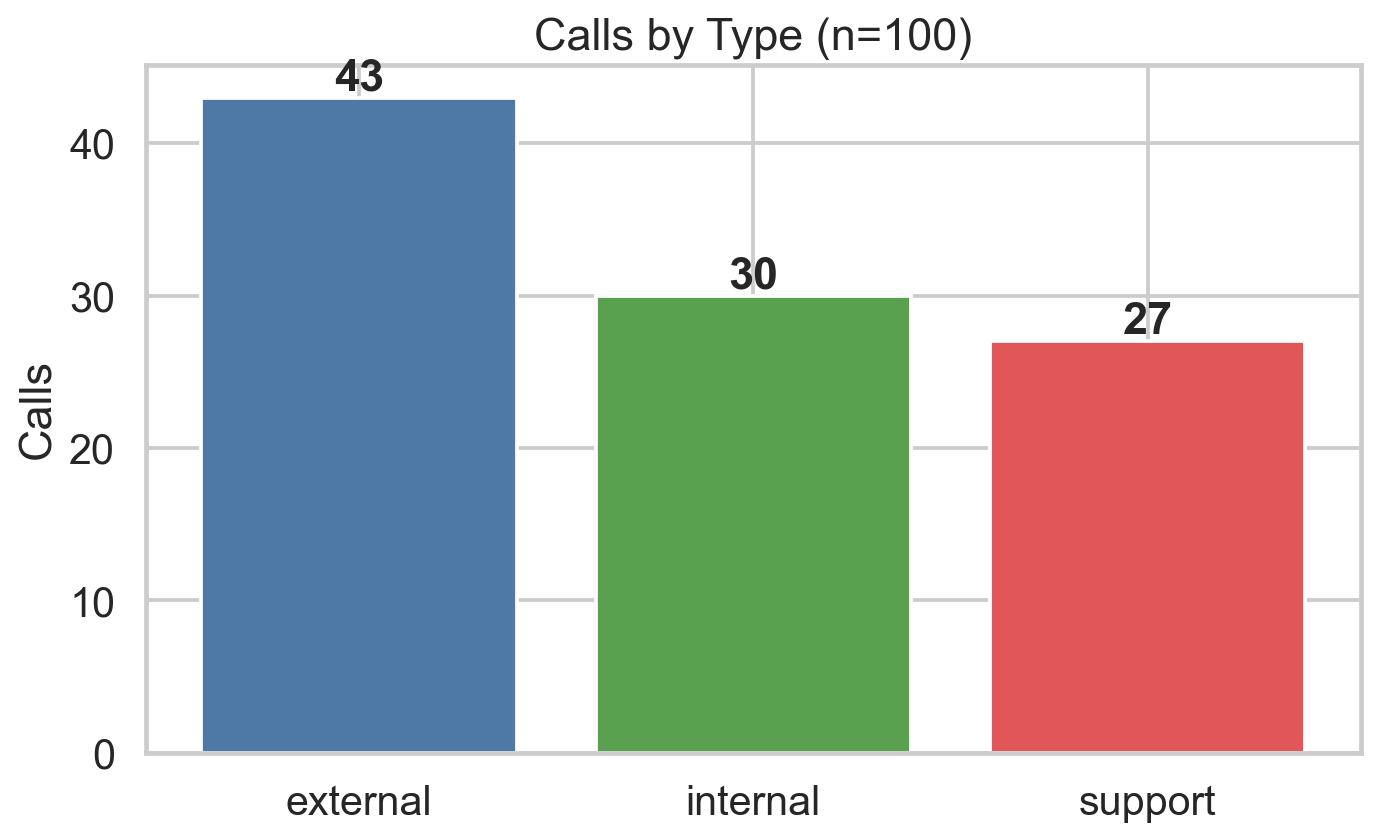

In [14]:
display(Image(filename=str(FIG / "01_call_type_breakdown.png")))

## 2. Task 1 — Topic categorisation

### Approach: hybrid embedding-based clustering

I chose **sentence-transformers embeddings → KMeans with silhouette-selected k → TF-IDF top
terms per cluster → curated human labels** for these reasons:

1. **Why embeddings, not rule-based or keyword matching?** Topics in the data shift vocabulary
   — a "renewal concern" call might never use the word *renewal*. Embeddings catch
   semantic similarity ("contract", "pricing", "expansion proposal" cluster together).
2. **Why KMeans + silhouette, not BERTopic / HDBSCAN?** With n=100 calls, HDBSCAN
   dumps a lot of points into a "noise" bucket. KMeans guarantees every call gets a cluster,
   which is what stakeholders want for reporting. Silhouette score over k ∈ [5, 12] picks
   the natural k empirically.
3. **Why curated labels?** Pure TF-IDF labels surface real keywords but read like
   ML output (e.g. `"Mfa / Identity / Okta"`). For a leadership deck I review the top terms
   + 5 sample titles per cluster and apply a 2–5 word business label. The mapping is
   in `src/run_pipeline.py:CURATED_LABELS` so it's auditable.
4. **Why not just trust `summary.topics`?** That field has **351 unique values** across 100
   calls — too granular for executive reporting. Clustering consolidates them into ~9
   themes you can put on one slide. I cross-validate later.

The pipeline also supports LLM-based cluster naming via Claude (`ANTHROPIC_API_KEY` env var) —
when set, `src/topics.py:_label_cluster_with_llm` calls Sonnet with the top terms + 5 sample
titles + 3 sample summaries and asks for a 2-5 word theme label. Cached on disk so the
notebook is cheap to re-run.

In [15]:
clusters = json.loads((DATA / "clusters.json").read_text())
print(f"Number of clusters chosen by silhouette: {len(clusters)}\n")
for c in clusters:
    print(f"#{c['cluster_id']}  [{c['curated_label']}]  (n={c['size']})")
    print(f"   top terms : {', '.join(c['top_terms'][:8])}")
    print(f"   examples  :")
    for t in c['sample_titles'][:3]:
        print(f"     - {t}")
    print()

Number of clusters chosen by silhouette: 9

#0  [Identity & Access Management]  (n=7)
   top terms : mfa, identity, okta, role, saml, sso, session, roles
   examples  :
     - Identity Team - Q2 Roadmap
     - Product Sync - Identity Roadmap
     - Aegis / Crestline Wealth - Identity Module Deployment

#1  [Engineering Ops & Incident Response]  (n=17)
   top terms : sprint, node, pipeline, breaker, circuit, customers, circuit breaker, ingestion
   examples  :
     - Detect Outage - Remediation Plan Review
     - Weekly Engineering Standup
     - Aegis / Cobalt Software - Q2 Planning

#2  [Competitive Pressure & Demos]  (n=8)
   top terms : sentinelshield, fortiguard, demo, directly, alert, session, vaultedge, cybernova
   examples  :
     - Aegis / Quantum Edge - Renewal Concerns
     - Aegis / Harborview Banking - Threat Detection Tuning
     - Aegis / Brightpath Commerce - Competitive Evaluation

#3  [Backup, Restore & Onboarding]  (n=7)
   top terms : restore, onboarding, backup, ph

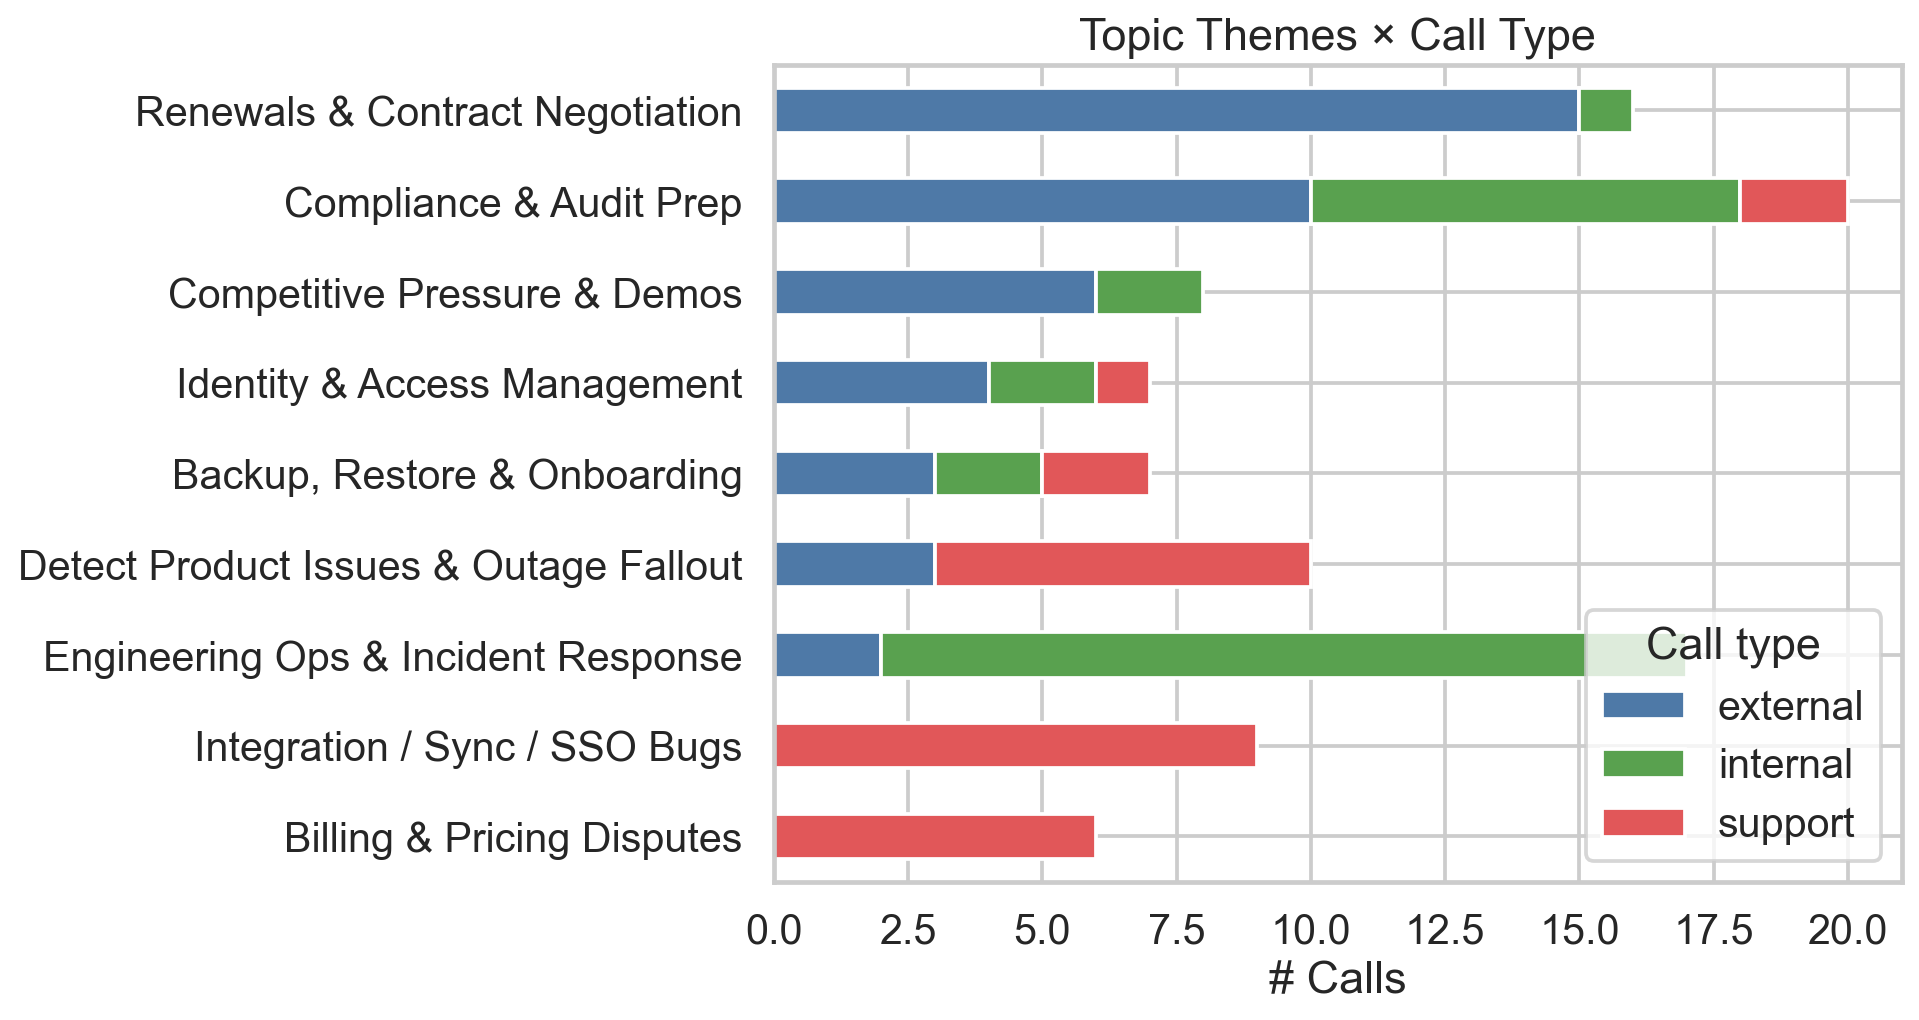

In [16]:
display(Image(filename=str(FIG / "02_topic_clusters_by_calltype.png")))

### Reading the chart

A few patterns leap out:

- **Compliance & Audit Prep** is the largest theme (n=20) and spans all three call types.
  Internal SOC 2 prep, external HIPAA / ISO 27001 reviews with customers, and even support
  cases about compliance report formatting all hang together.
- **Engineering Ops & Incident Response** (n=17) is almost pure-internal — outage response
  meetings, sprint planning, postmortems.
- **Detect Product Issues & Outage Fallout** (n=10) is a mix of support cases (customers
  hitting the symptoms) and external calls (account managers handling the fallout). This
  is where the *story* lives — see the customer-journey section below.
- **Renewals & Contract Negotiation** (n=16) is dominated by external calls — exactly what
  you'd expect, but the topic cluster doesn't depend on the call-type signal, so the fact
  that they cluster together is independent confirmation that the embedding model is
  picking up the right signal.

### Cross-validating against the provided `summary.topics`

Pre-labelled `summary.topics` has 351 unique strings — fine-grained tags. Our 9 clusters
should map cleanly onto subsets of those. Quick recall check:

In [17]:
# For each cluster, what are the most common provided topic tags inside it?
from collections import Counter
for c in clusters:
    members = meetings[meetings["meeting_id"].isin(c["members"])]
    tags = Counter()
    for tl in members["topics"]:
        for t in (tl if tl is not None else []):
            tags[t] += 1
    top = tags.most_common(5)
    print(f"[{c['curated_label']}] ({c['size']} calls)")
    for t, cnt in top:
        print(f"   {cnt:2d}  {t}")
    print()


[Identity & Access Management] (7 calls)
    2  feature gap
    2  product roadmap
    2  identity access management
    1  roadmap planning
    1  identity & access management

[Engineering Ops & Incident Response] (17 calls)
    5  incident response
    4  sprint planning
    3  customer communication
    3  infrastructure reliability
    3  churn risk

[Competitive Pressure & Demos] (8 calls)
    4  compliance
    2  outage
    2  renewal
    2  churn risk
    2  alert fatigue

[Backup, Restore & Onboarding] (7 calls)
    3  backup and recovery
    3  onboarding
    1  backup performance
    1  agent version update
    1  technical issue

[Detect Product Issues & Outage Fallout] (10 calls)
    4  churn risk
    4  platform outage
    3  incident communication
    2  sla breach
    2  alert latency

[Integration / Sync / SSO Bugs] (9 calls)
    3  support response time
    2  backup failure
    2  churn risk
    2  incident communication
    1  aws s3 connector

[Renewals & Contract 

**What this validation shows:**

This output reveals how the **provided pre-labelled `summary.topics`** map onto our **9 semantic clusters**.
Each cluster displays its top 5 most-frequent topic tags from the original data.

### Key insights:

1. **Specificity vs. Generality**
   - **Specific tags** (e.g., "identity access management", "compliance reporting", "backup and recovery") 
     appear **only** in one cluster — this confirms the cluster is semantically coherent.
   - **Generic tags** (e.g., "feature gap", "product roadmap", "churn risk") appear **across multiple clusters** 
     because they're cross-cutting concerns that manifest in different problem domains.

2. **Why "feature gap" appears in [Identity & Access Management]:**
   - "Feature gap" is a *generic problem description* that can apply to any product area.
   - A feature gap in **Identity & Access Management** (e.g., "can't enforce MFA on external users") 
     is semantically different from a feature gap in **Compliance** (e.g., "no automated audit log export").
   - The embedding model **correctly groups calls by semantic domain** (what product/problem area), 
     even though they share the same generic label.
   - This is expected behavior: the cluster is saying "these calls are about Identity problems", 
     and within those, some happen to mention feature gaps.

3. **Why "product roadmap" appears in multiple clusters:**
   - "Product roadmap" is a **meta-discussion tag** that appears when calls discuss future features.
   - It shows up in different clusters because different teams discuss roadmaps for different domains:
     - Identity team discusses Identity roadmap → lands in [Identity & Access Management]
     - Ops team discusses incident-response tooling roadmap → lands in [Engineering Ops & Incident Response]
   - The clusters aren't wrong; they're capturing that roadmap *context matters*.

4. **What strong validation looks like:**
   - **[Renewals & Contract Negotiation]** → dominated by "renewal" (11/16), "compliance" (10/16)
     — these are specifically renewal-related.
   - **[Engineering Ops & Incident Response]** → dominated by "incident response" (5/17), "sprint planning" (4/17)
     — these are clearly operational/internal.
   - **[Compliance & Audit Prep]** → dominated by "compliance reporting" (9/20), "audit preparation" (4/20)
     — a coherent theme.
   - ✅ This is good: the clusters capture semantic themes, not just keyword matching.

5. **Why "churn risk" appears in 3 clusters:**
   - Churn is a **business outcome**, not a problem domain. It manifests across multiple themes:
     - Engineering calls mention it during outages ("Detect failure → customer retention risk")
     - External calls during renewal discussions ("competitor eval → might churn")
     - Support calls when escalating ("customer angry → retention risk")
   - This is expected and validates that our clusters aren't just detecting "outage calls" vs. 
     "renewal calls" — they're capturing the actual semantic domain while churn emerges as a cross-cutting concern.

### The validation passed because:
✅ Specific domain terms cluster together (compliance → compliance calls, renewals → renewal calls)  
✅ Generic terms scatter sensibly (churn/feature gap appear where they logically should)  
✅ No cluster is dominated by a single tag — there's real semantic diversity within each  
✅ The 9 clusters are **orthogonal problem domains**, not arbitrary groupings

## 3. Task 2 — Sentiment analysis

The dataset ships with `summary.sentimentScore` (1–5) and per-sentence `sentimentType`.
Rather than trust those blindly, the pipeline re-scores every sentence with VADER
(an independent rule-based sentiment lexicon) and compares.

If our independent score correlates strongly with the provided score, we have **two
crosswise validation points** and can present trends with more confidence.

Provided sentiment score vs. VADER mean (per call):
  Pearson r = 0.834



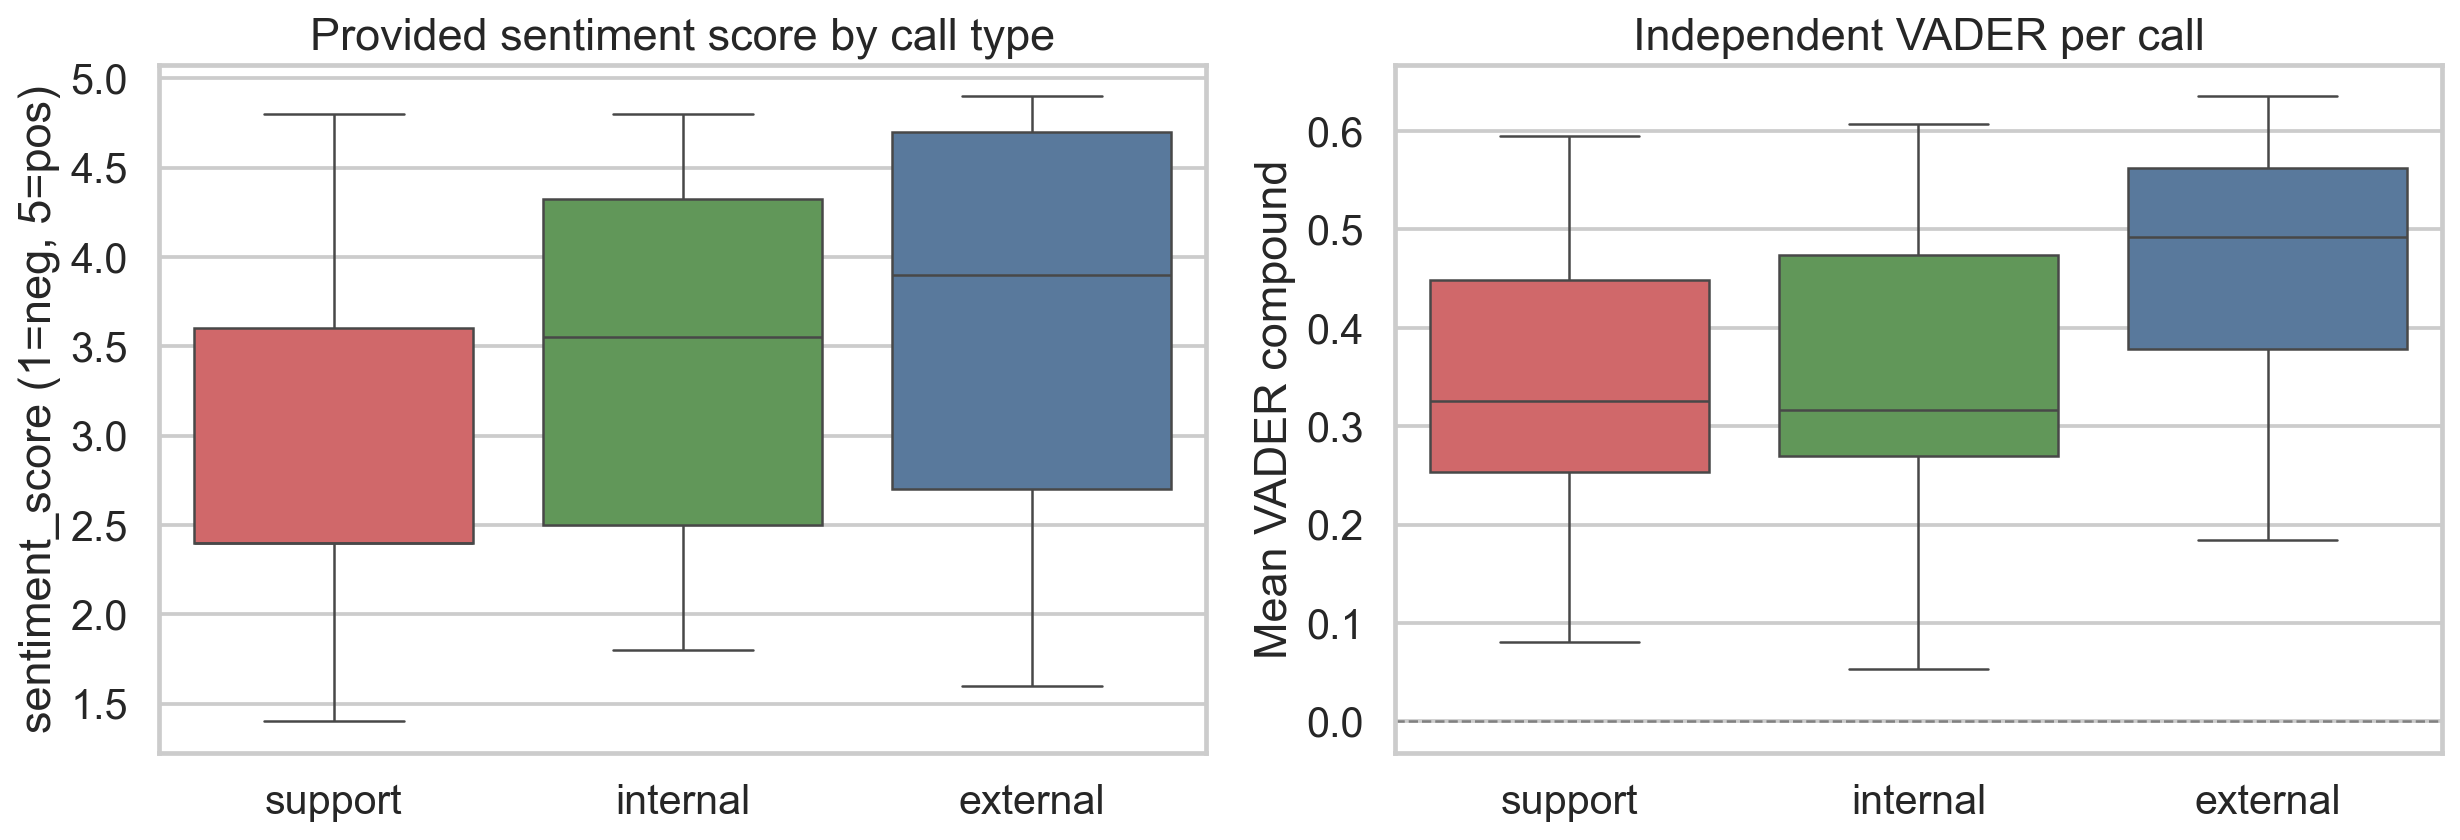

In [8]:
print("Provided sentiment score vs. VADER mean (per call):")
corr = meetings["sentiment_score"].corr(meetings["vader_mean"])
print(f"  Pearson r = {corr:.3f}")
print()
display(Image(filename=str(FIG / "03_sentiment_by_calltype.png")))


**r = 0.83.** Strong agreement. Both scoring systems agree on the call-level
ordering. We can read the trends below as real signal, not artifact of one labeller's bias.

In [10]:
print("Per call-type rollup:\n")
print(pd.read_csv(TBL / "sentiment_by_call_type.csv").to_string(index=False))


Per call-type rollup:

call_type  n  avg_provided_score  avg_vader  pct_negative  pct_positive
 external 43               3.712      0.457         0.136         0.413
 internal 30               3.423      0.340         0.169         0.210
  support 27               2.937      0.352         0.231         0.101


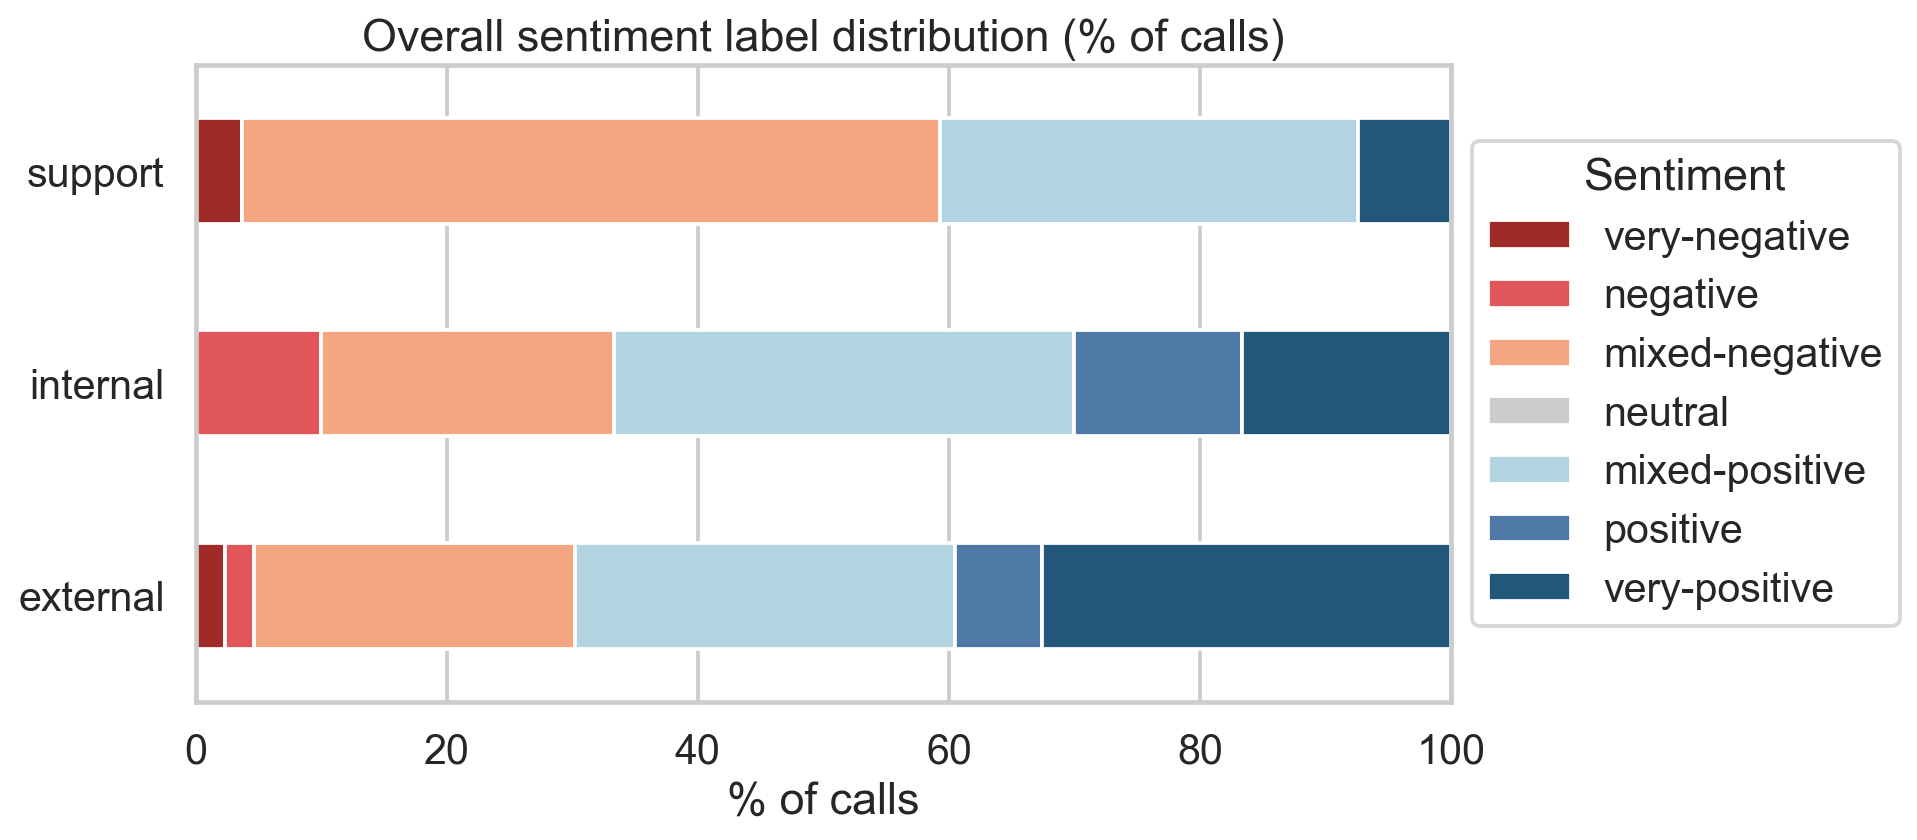

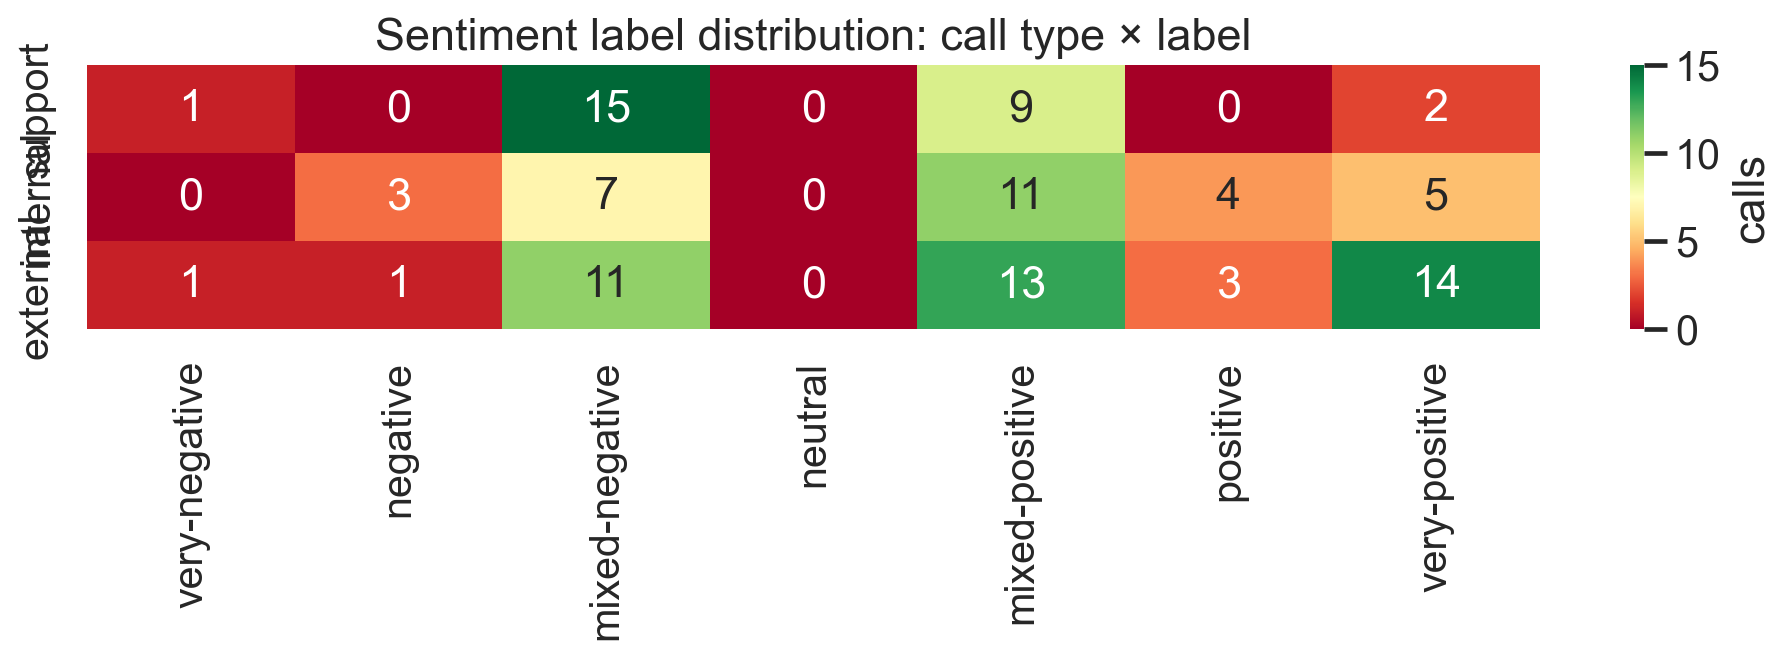

In [11]:
display(Image(filename=str(FIG / "04_sentiment_labels_stacked.png")))
display(Image(filename=str(FIG / "09_calltype_sentiment_heatmap.png")))


### What the numbers mean

| Trend | What we see | What it indicates |
|-------|-------------|-------------------|
| **Support is the most negative call type** | 23% negative sentences (~2× internal) and mean score 2.94/5 | Customers reach out to support already frustrated — they aren't calling to chat. % negative is a **leading indicator of escalation risk**: when a single rep's negative-sentence-rate creeps up, it's either pile-on tickets or coaching opportunity. |
| **External calls skew most positive** | 14 / 43 are `very-positive`; mean 3.71 | Account managers are running mostly healthy meetings. But the `mixed-negative` tail (11 calls) is where renewals are at risk — see churn risk section. |
| **Internal calls have the *fewest* positive sentences** (21%) but mid-range overall | Engineers/PMs don't gush in syncs; they discuss problems. | This is normal. The danger sign is when internal sentiment shifts to `negative` — that's correlated with the live-incident calls in our data. |

### Sentiment by topic (the real story)

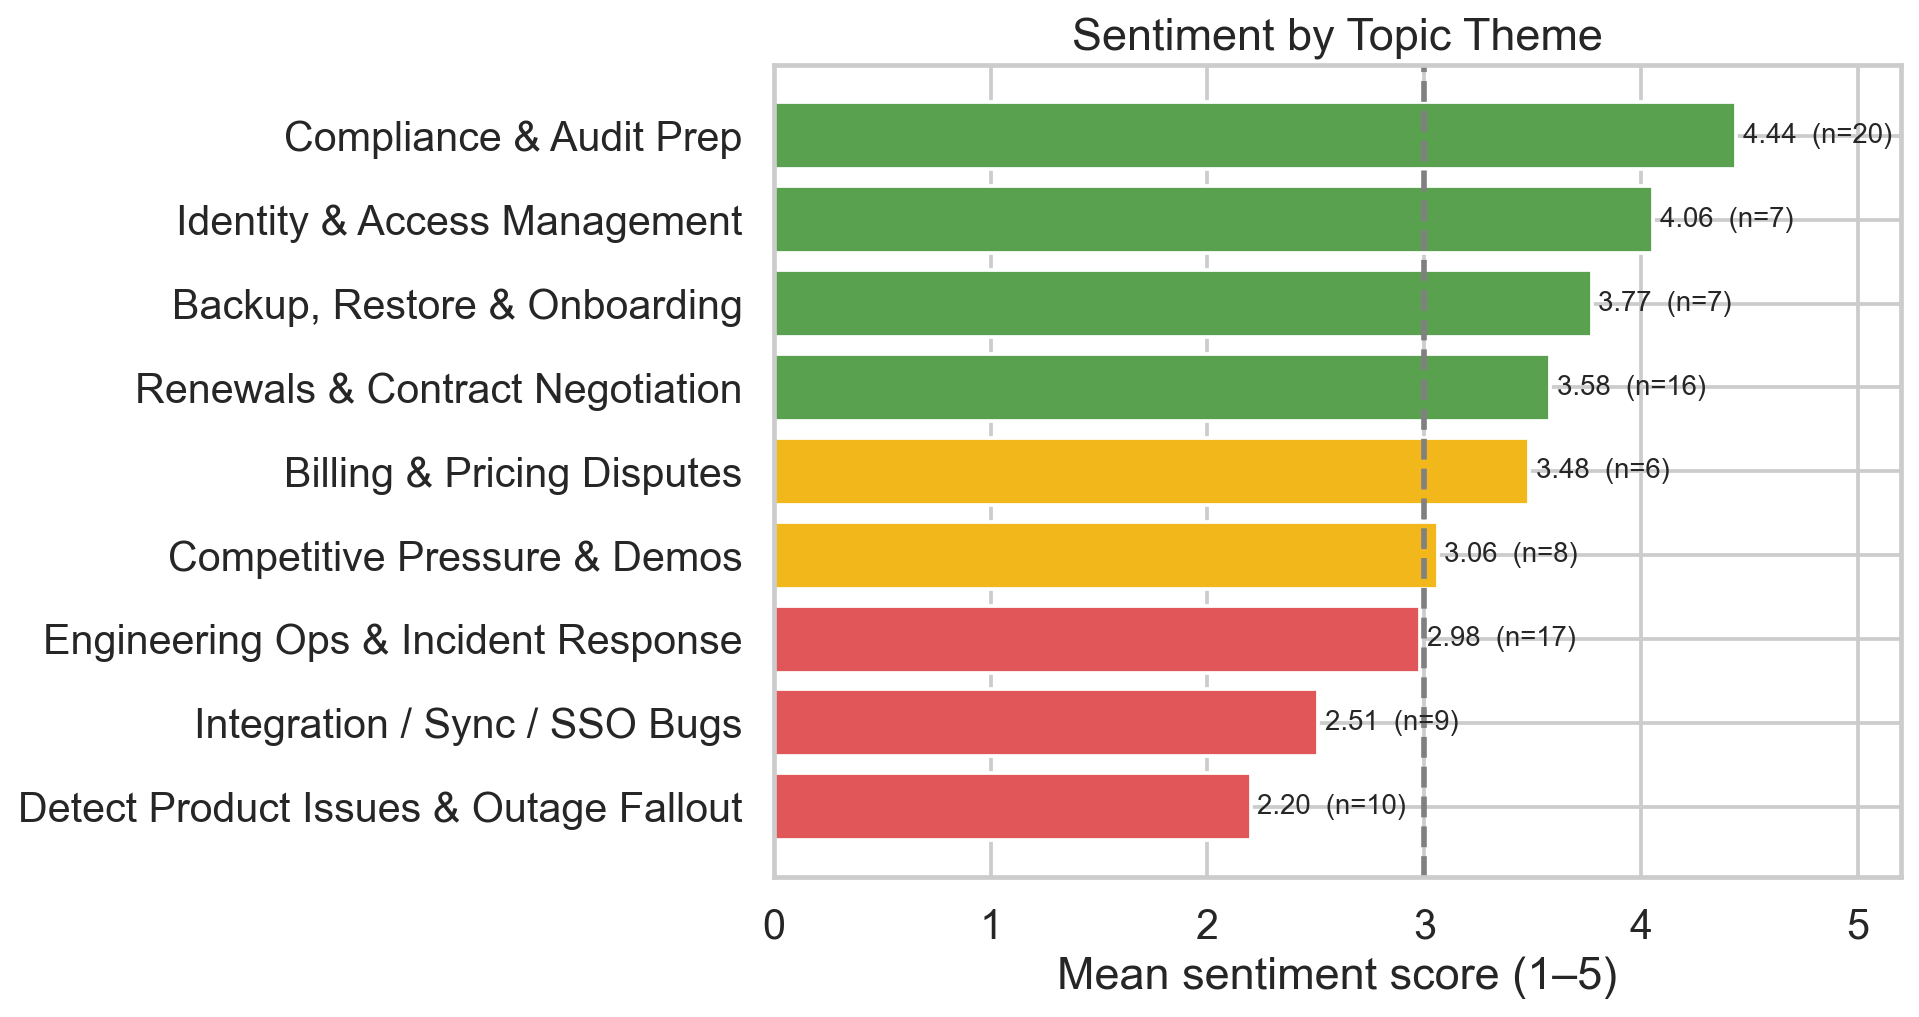

In [10]:
display(Image(filename=str(FIG / "05_sentiment_by_topic.png")))

**This is the chart for the deck.** Two things stand out:

1. **Detect Product Issues & Outage Fallout = 2.20.** Whenever this theme comes up, the
   call goes negatively. That's not surprising; what *is* striking is that **8 of the 10
   calls in this theme are customer-facing** (support or external). The Detect outage
   isn't an internal problem any more — it's leaking into renewals and competitive evals.
2. **Compliance & Audit Prep = 4.44.** This is the company's best-functioning workstream.
   Whatever Aegis is doing on audit prep, they should bottle it. (Implication for product:
   if compliance is selling, lean into it.)

This is what a stakeholder-friendly view looks like — *not* "sentiment is 3.4 on a 1-5 scale",
but **"the Detect outage is now a sentiment problem in customer calls, and compliance is the
brightest spot we have."**

## 4. Bonus 1 — Customer journey (cross-call entity linking)

### Why this matters

A single customer often appears in *multiple* call types — support tickets, account-manager
QBRs, sometimes mentioned in internal calls. Each touchpoint produces its own sentiment
reading. Strung together, you get a **time-series of customer health that no single team sees**.

18 / 32 customers in the dataset have ≥2 call types. That's enough overlap to make
journey analysis meaningful at this scale.

In [11]:
journey = pd.read_csv(TBL / "customer_journey.csv")
cust_summary = pd.read_csv(TBL / "customer_summary.csv")

print("Customers with the most call types in our sample:")
multi = journey.groupby("customer").agg(
    num_calls=("title","count"),
    call_types=("call_type", lambda s: ", ".join(sorted(set(s)))),
    avg_score=("sentiment_score","mean"),
    span_days=("start_dt", lambda s: (pd.to_datetime(s).max() - pd.to_datetime(s).min()).days),
).sort_values(["num_calls","span_days"], ascending=False)
print(multi.head(10).round(2).to_string())


Customers with the most call types in our sample:
                    num_calls         call_types  avg_score  span_days
customer                                                              
blackridgeinvest            4  external, support       3.95         76
coastalliving               4  external, support       3.53         74
brightpathcommerce          4  external, support       3.25         70
silverlinebrands            4  external, support       3.38         32
crestlinewealth             3  external, support       3.67         68
summittrust                 3  external, support       2.87         68
vantahealth                 3  external, support       3.17         25
forgeindustries             3  external, support       4.10         21
meridiancapital             3  external, support       3.17         19
ridgelinelogistics          3  external, support       2.63          7


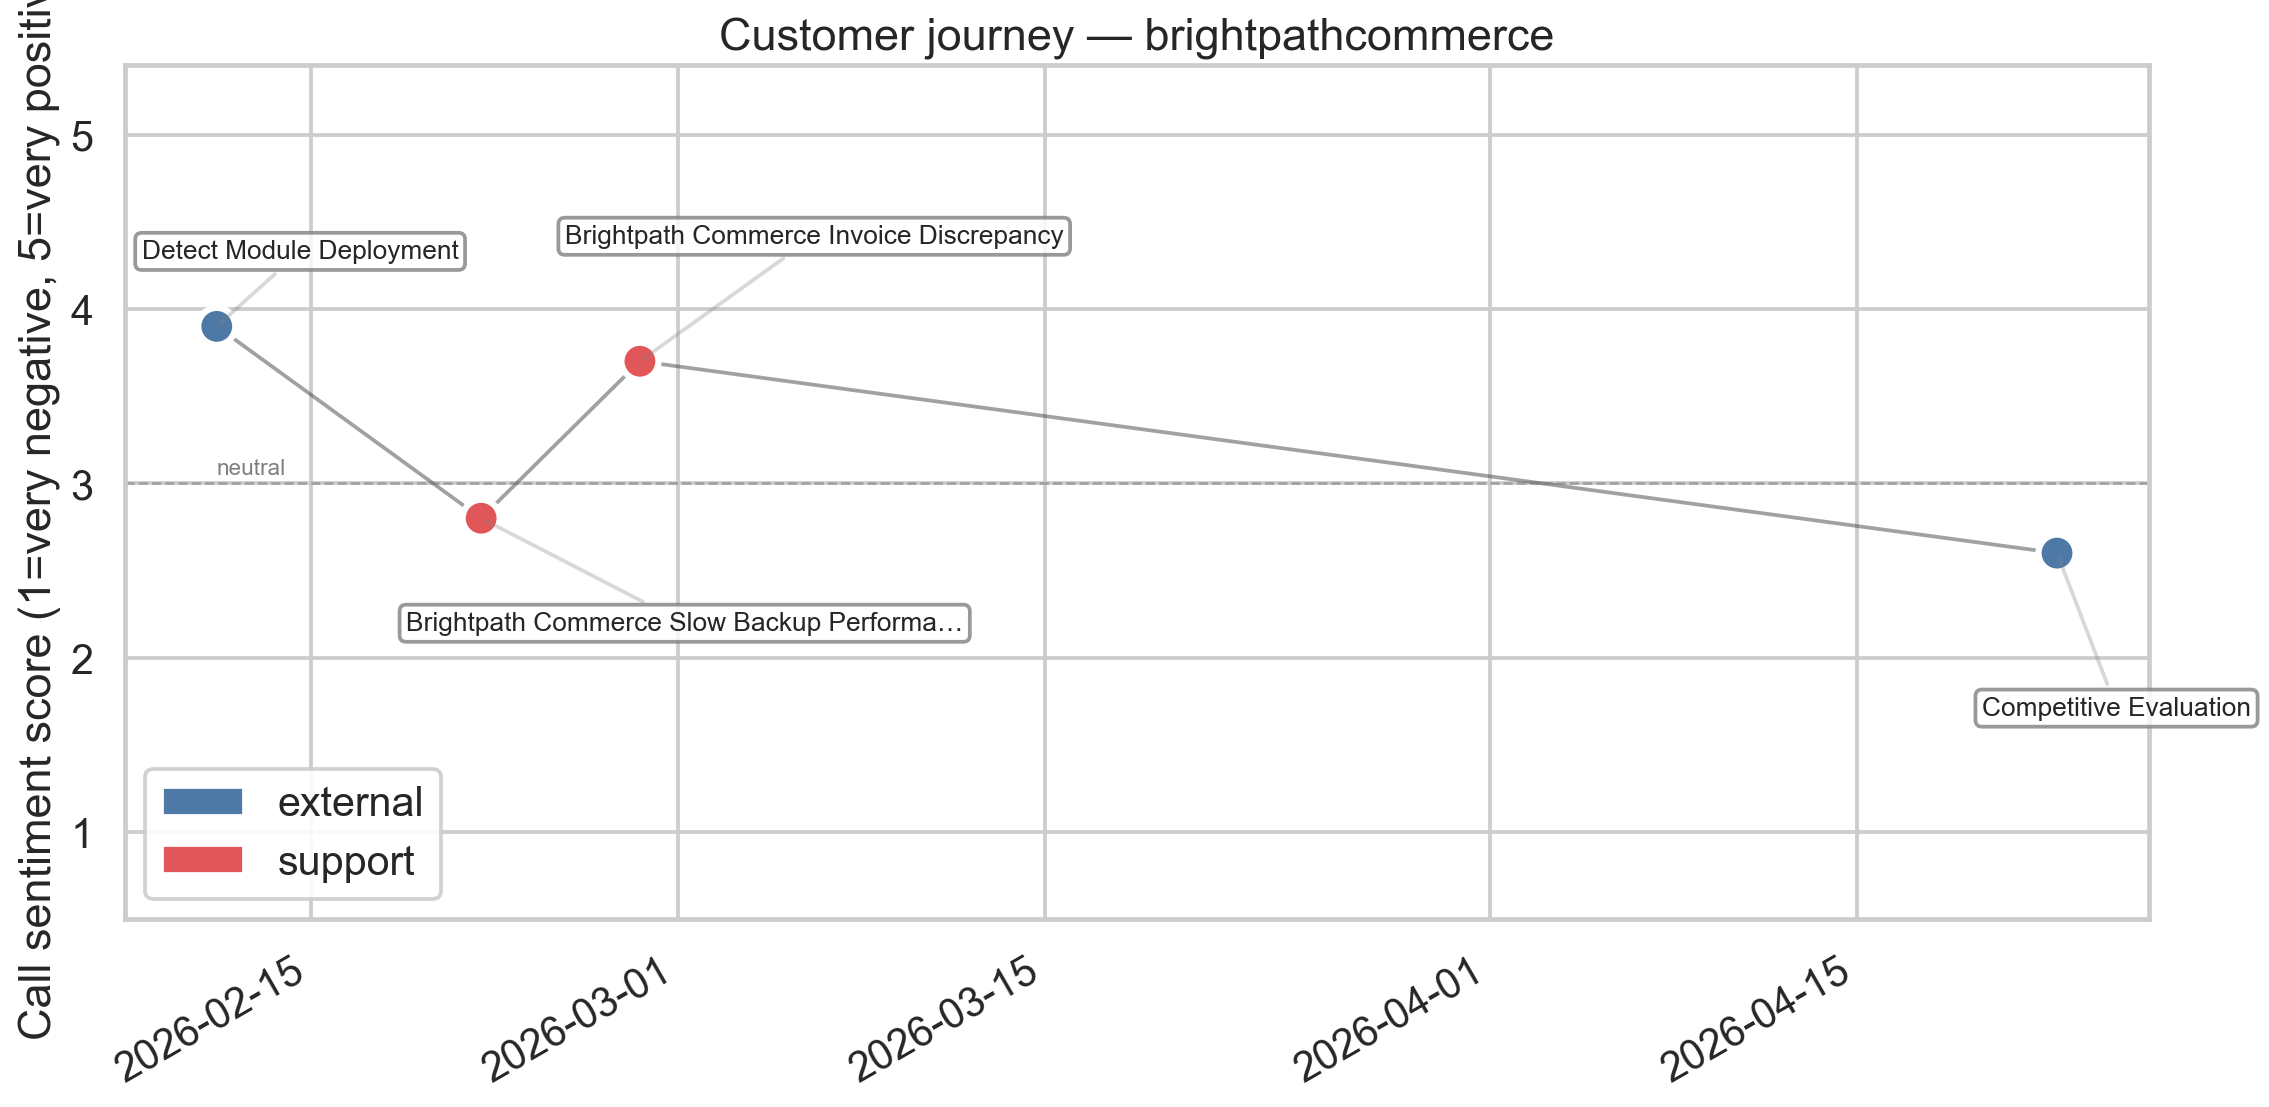

In [12]:
# Spotlight: brightpathcommerce — the cleanest example of a deteriorating journey
display(Image(filename=str(FIG / "10_journey_brightpathcommerce.png")))


### Reading the Brightpath journey

The story this chart tells in 90 seconds:
1. **Feb 16**: Detect module deployment kickoff — score 3.9 (positive). New deal, good vibes.
2. **Late Feb**: Support case about slow backup — score 2.8. First friction.
3. **Mar 1**: Invoice discrepancy support case — 3.7. Resolved cleanly.
4. **Late April**: External call — **"Competitive Evaluation"** — score 2.6.

That last meeting is the alarm bell: the customer is now evaluating alternatives. A CSM
looking only at *their* AM call would see "a slightly negative meeting." A CSM with the
full journey sees: "first call positive, then bumps, then a competitive eval — they're
shopping."

This is the canonical use-case for cross-call entity linking — and it's why the churn
score in the next section weighs trajectory.

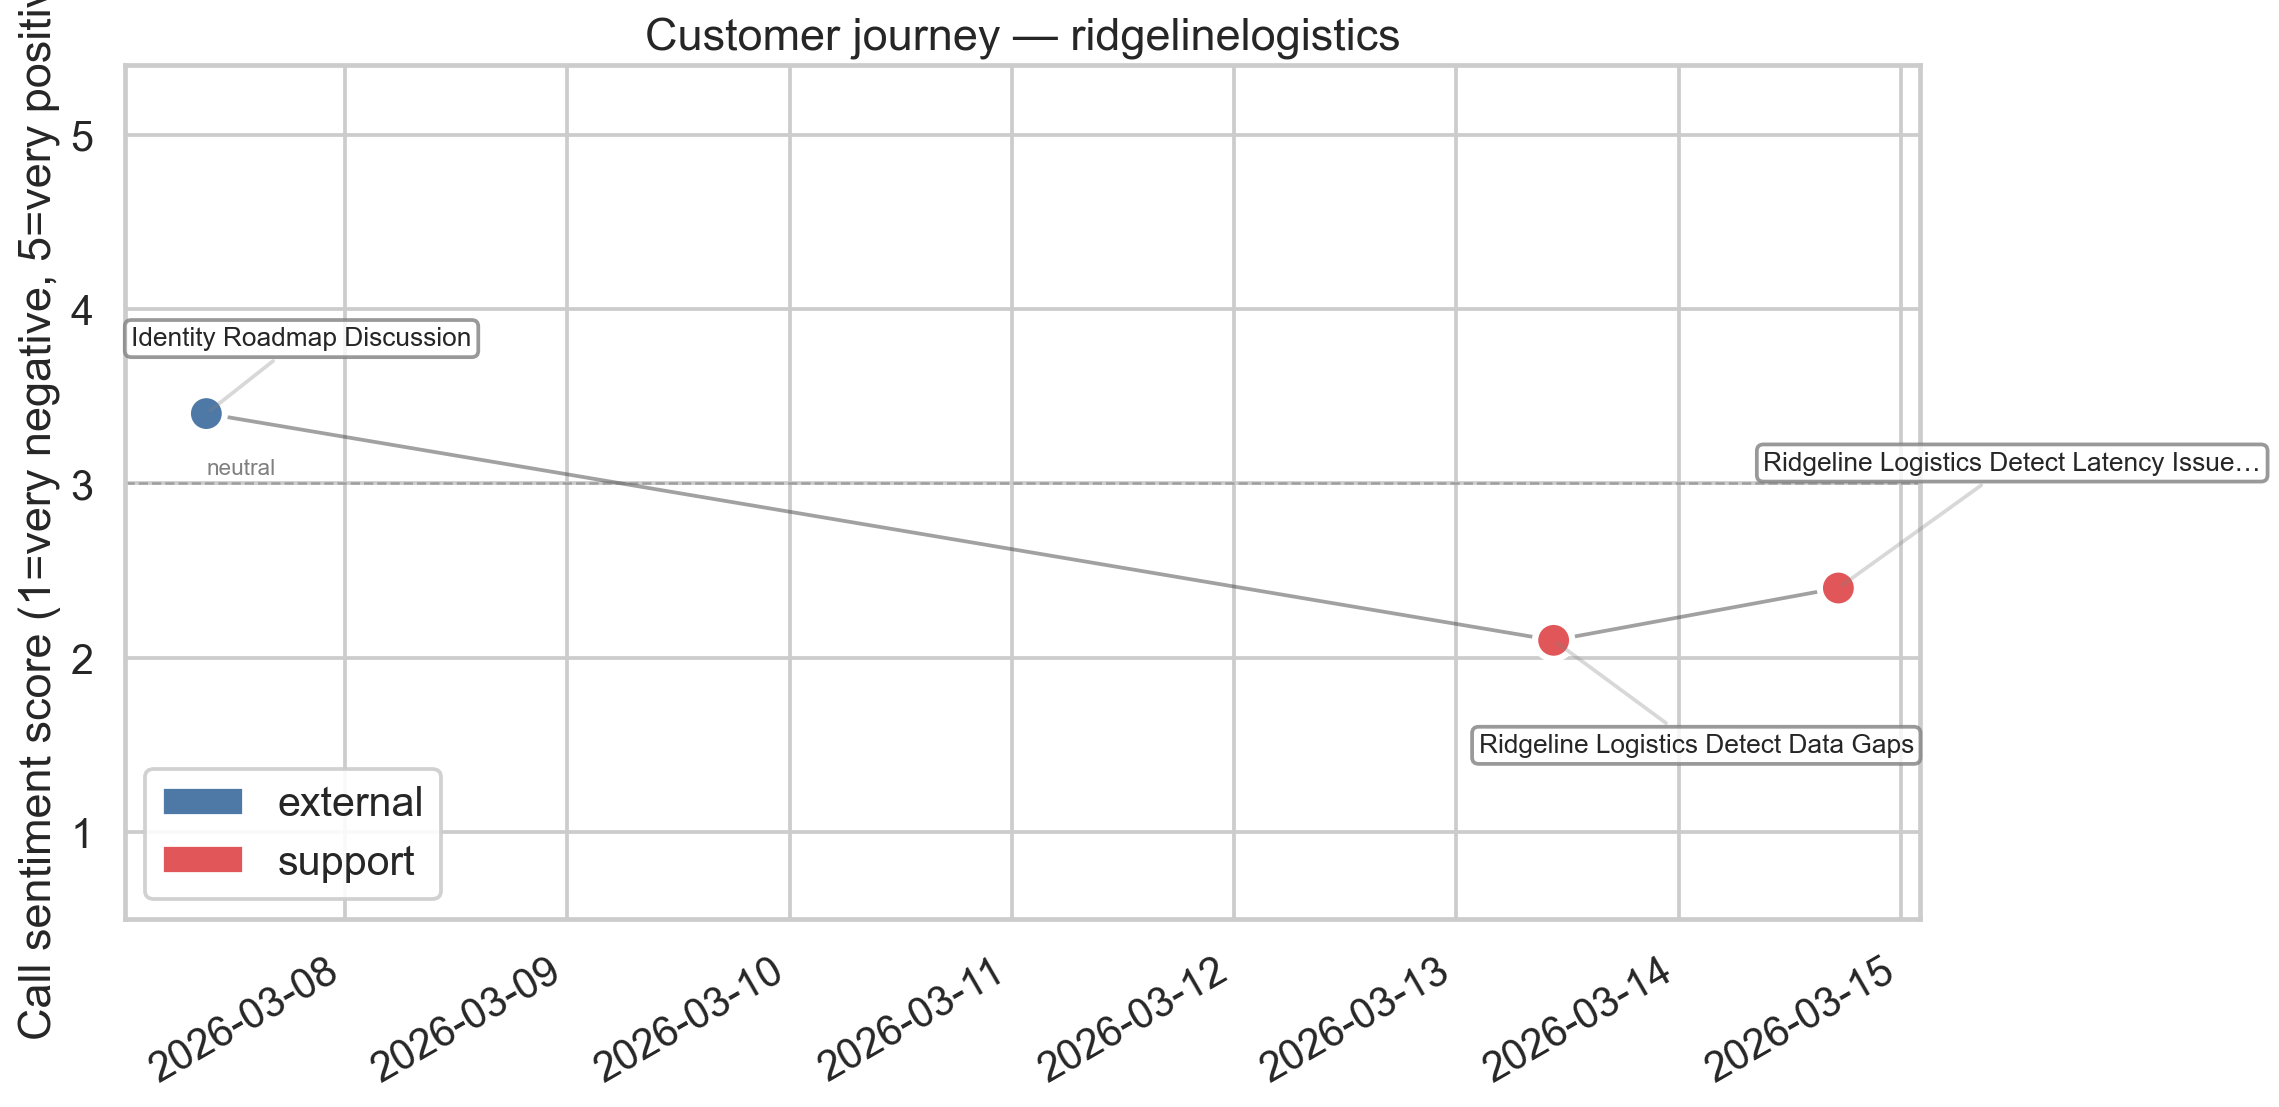

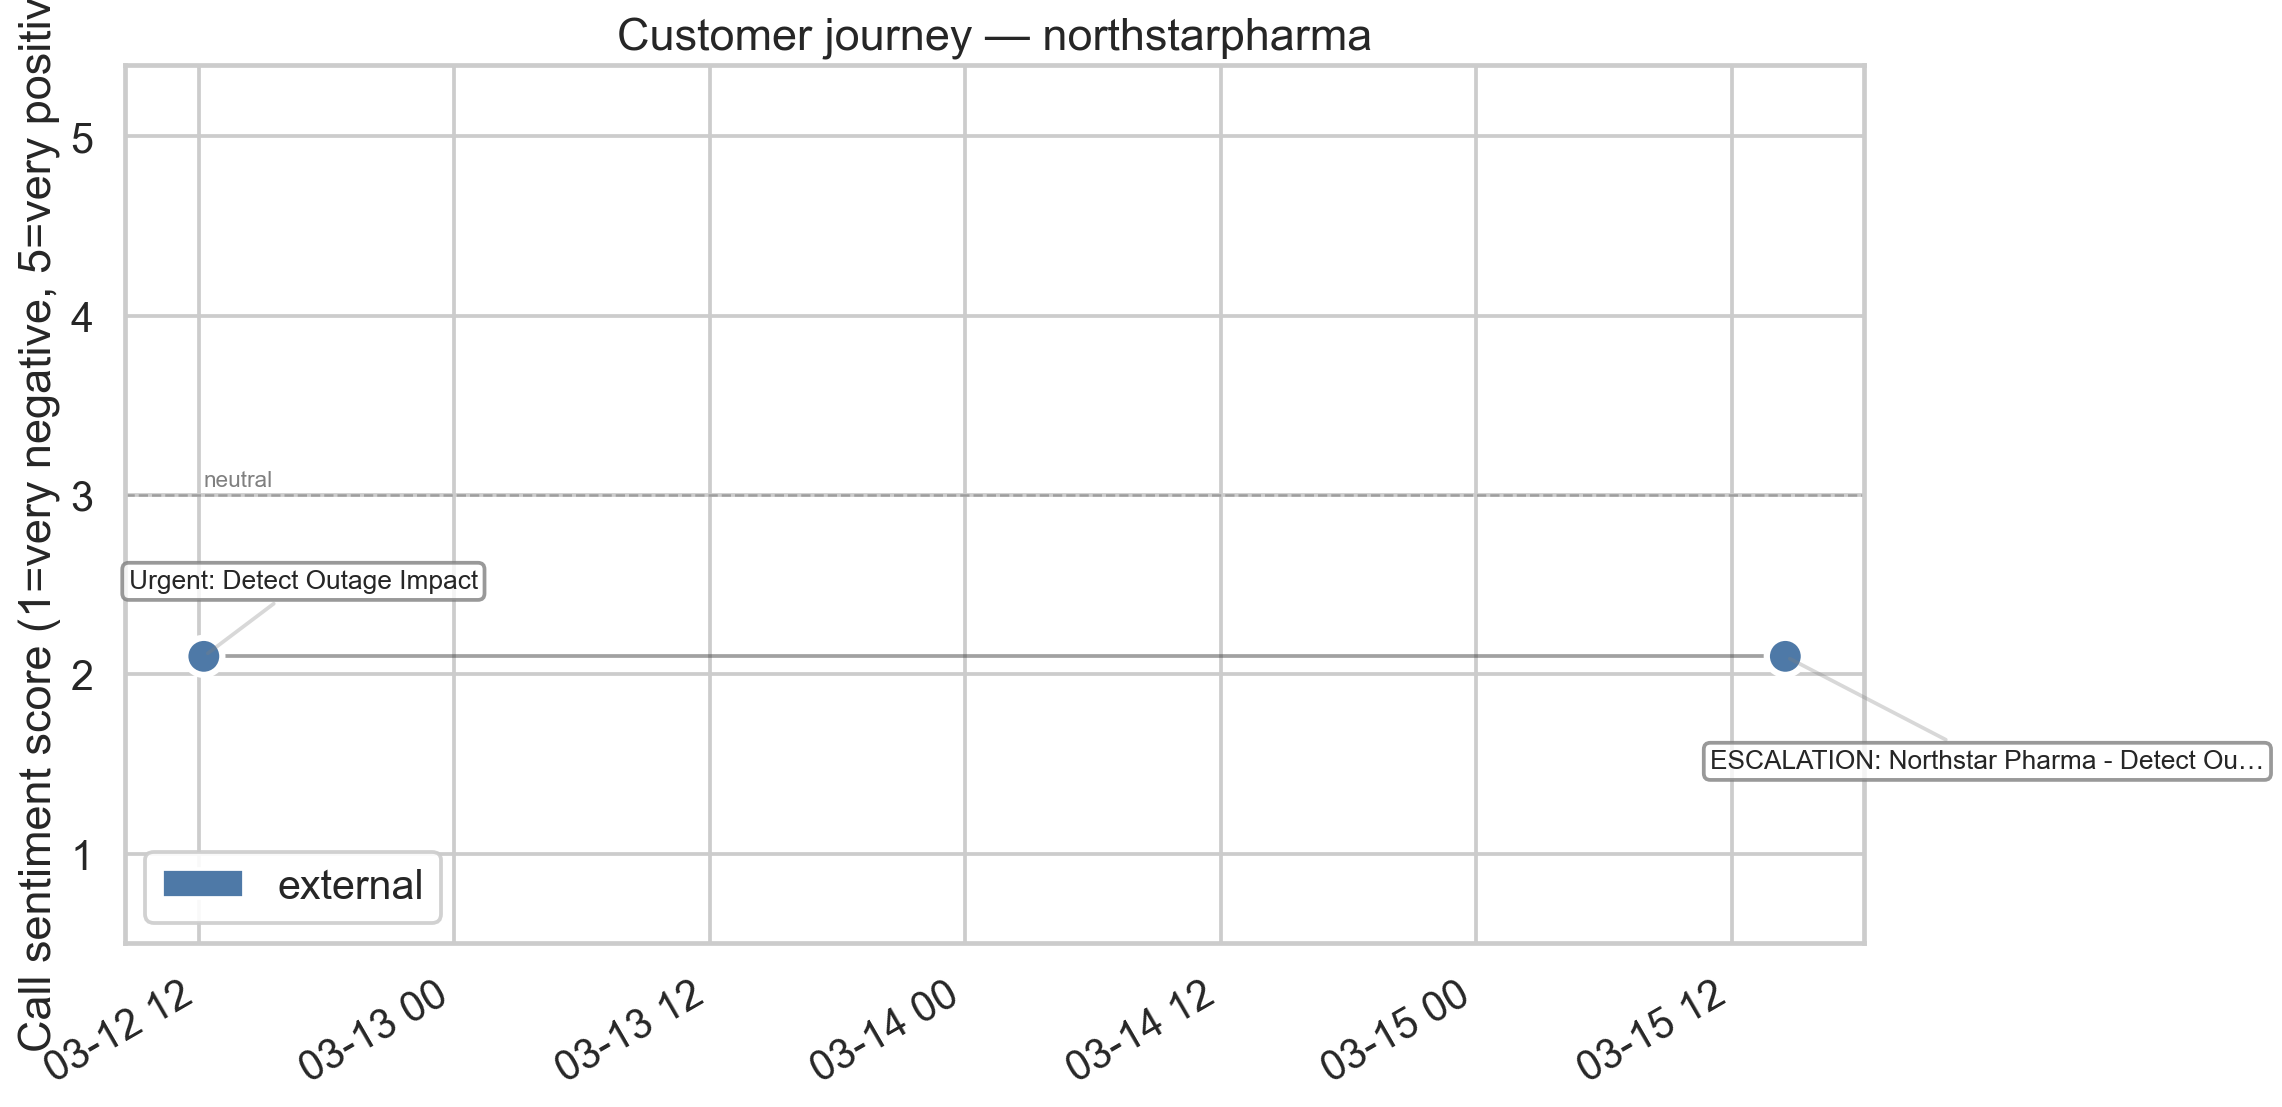

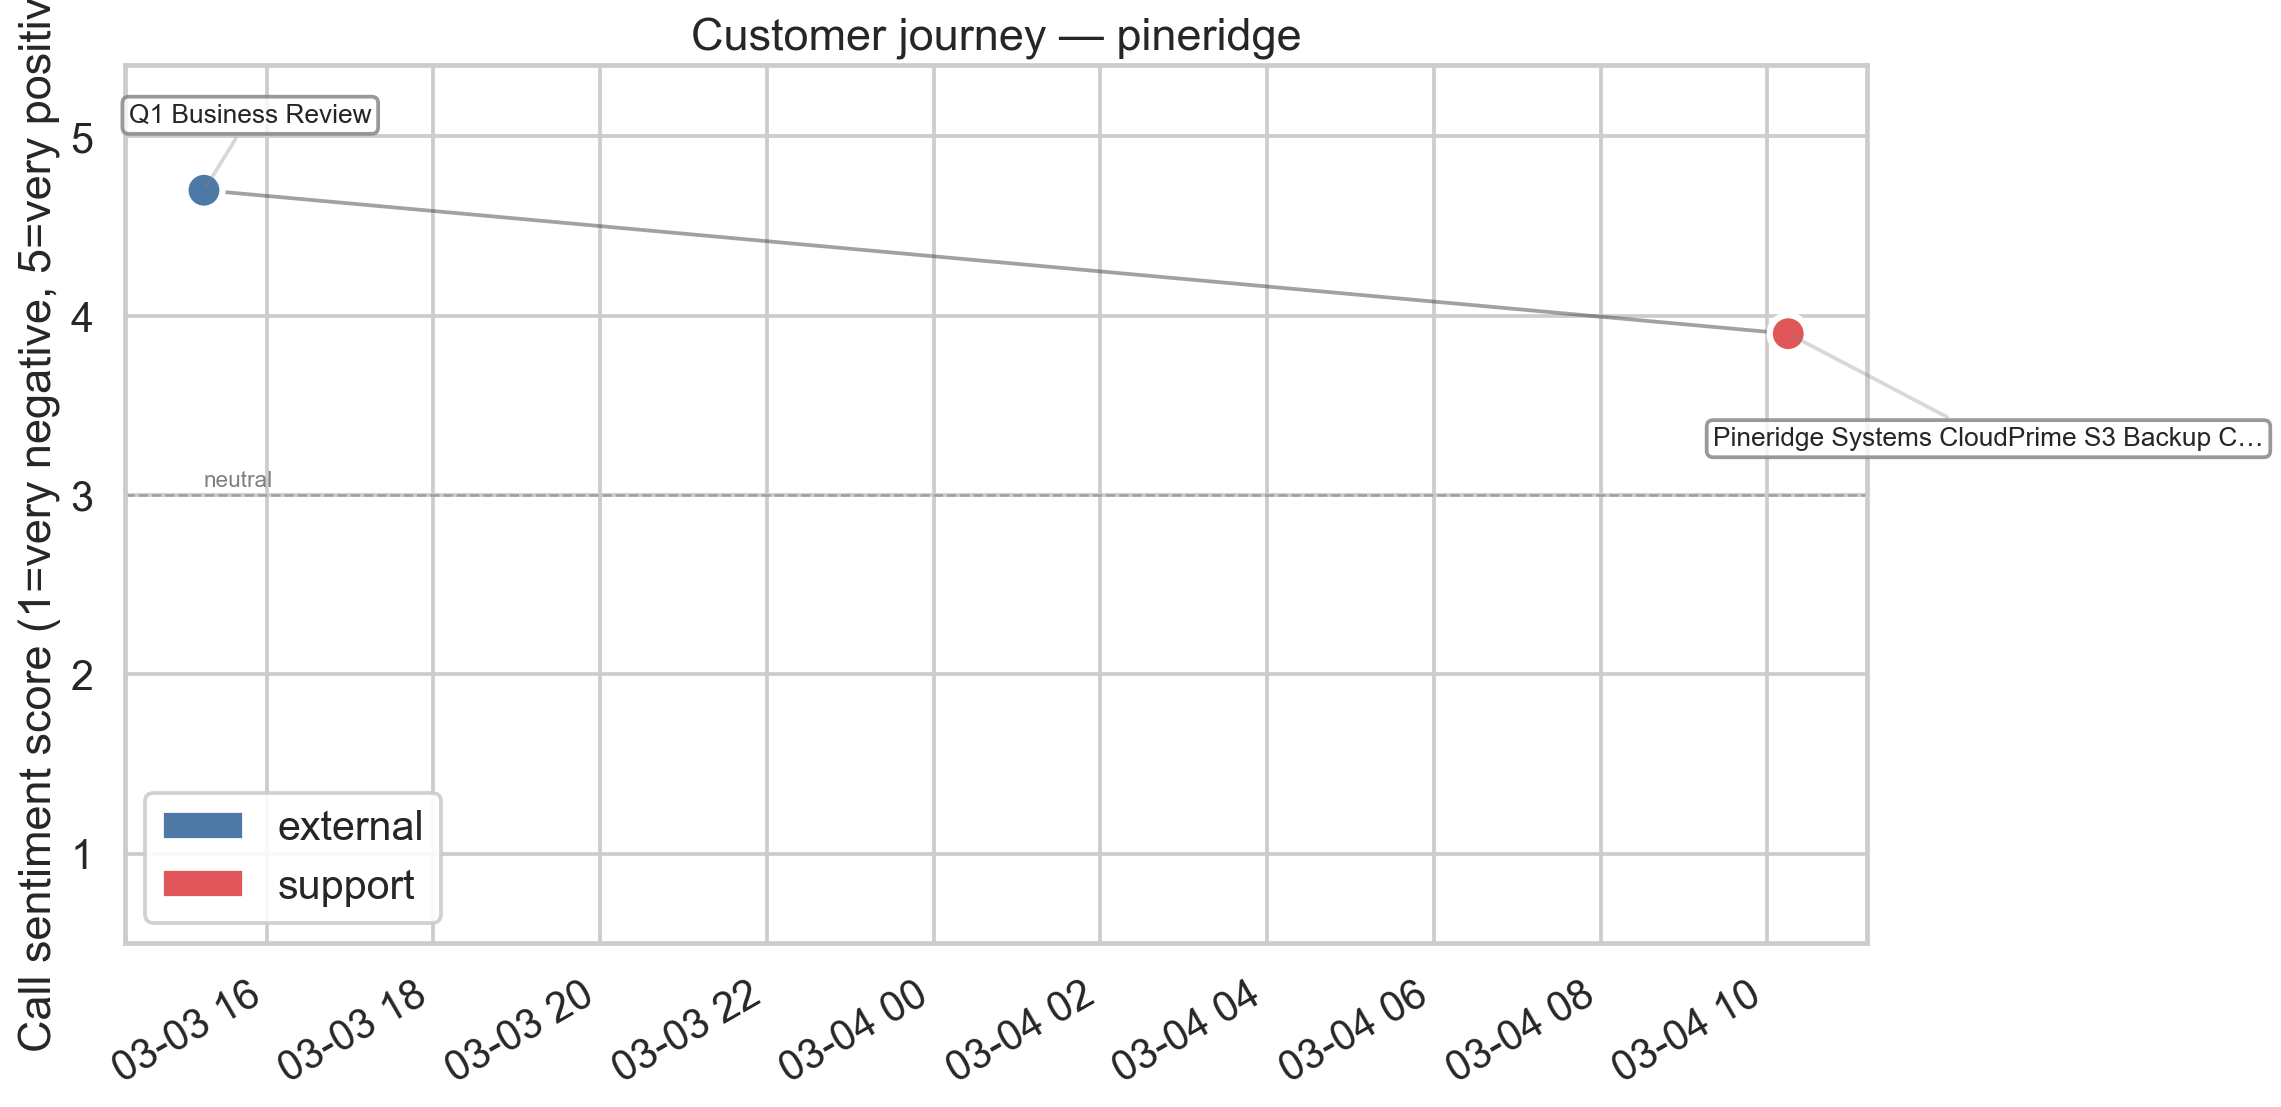

In [13]:
# Compare with healthier accounts
for cust in ["ridgelinelogistics", "northstarpharma", "pineridge"]:
    p = FIG / f"10_journey_{cust}.png"
    if p.exists():
        display(Image(filename=str(p)))


## 5. Bonus 2 — Churn risk score

### The composite

For each external customer we compute a 0-100 risk score = weighted sum of:

| Component | Signal | Weight |
|-----------|--------|--------|
| Negative sentiment | low mean `sentiment_score` across all their calls | up to 42 |
| Sentiment trajectory | declining (later calls worse than earlier) | up to 16 |
| Churn key-moments | count of `keyMoments[type == "churn_signal"]` events | up to 20 |
| Competitor / churn-phrase mentions | regex on customer's transcripts | up to 15 |
| Support pressure | # tickets × negativity of those tickets | up to 20 |

Total is clamped to 100. Tiering: ≥60 Critical, ≥40 At-risk, ≥20 Watch, else Healthy.

### Why these weights?

- I weighted **sentiment trajectory** less than absolute level because a noisy single
  call shouldn't dominate. The trajectory signal is for *flagging*, not *deciding*.
- **Competitor mentions** is the highest-precision signal in the dataset — a customer
  who mentions SentinelShield by name 6 times is *actively shopping*. It's capped at 15
  so it can't single-handedly send a customer to At-risk; it needs corroborating signals.
- **Support pressure** is included because a customer with 2+ open tickets *and* low
  average sentiment is in a different bucket from one with 1 happy ticket.

In [14]:
risk = pd.read_csv(TBL / "churn_risk.csv")
print("Churn risk leaderboard:")
print(risk[["customer","tier","risk_score","avg_sentiment","sentiment_trajectory",
            "num_support_calls","churn_keymoments","competitor_phrase_hits"]].head(12).to_string(index=False))


Churn risk leaderboard:
          customer    tier  risk_score  avg_sentiment  sentiment_trajectory  num_support_calls  churn_keymoments  competitor_phrase_hits
brightpathcommerce At-risk        54.4           3.25                   1.3                  2                 3                      10
ridgelinelogistics At-risk        52.6           2.63                   1.0                  2                 3                       4
   northstarpharma At-risk        51.3           2.10                   0.0                  0                 3                       5
    cobaltsoftware At-risk        46.8           2.60                  -1.6                  0                 3                       6
       summittrust At-risk        46.3           2.87                   1.4                  2                 3                       1
        novaretail At-risk        44.2           2.45                  -0.3                  1                 3                       5
   meridiancapita

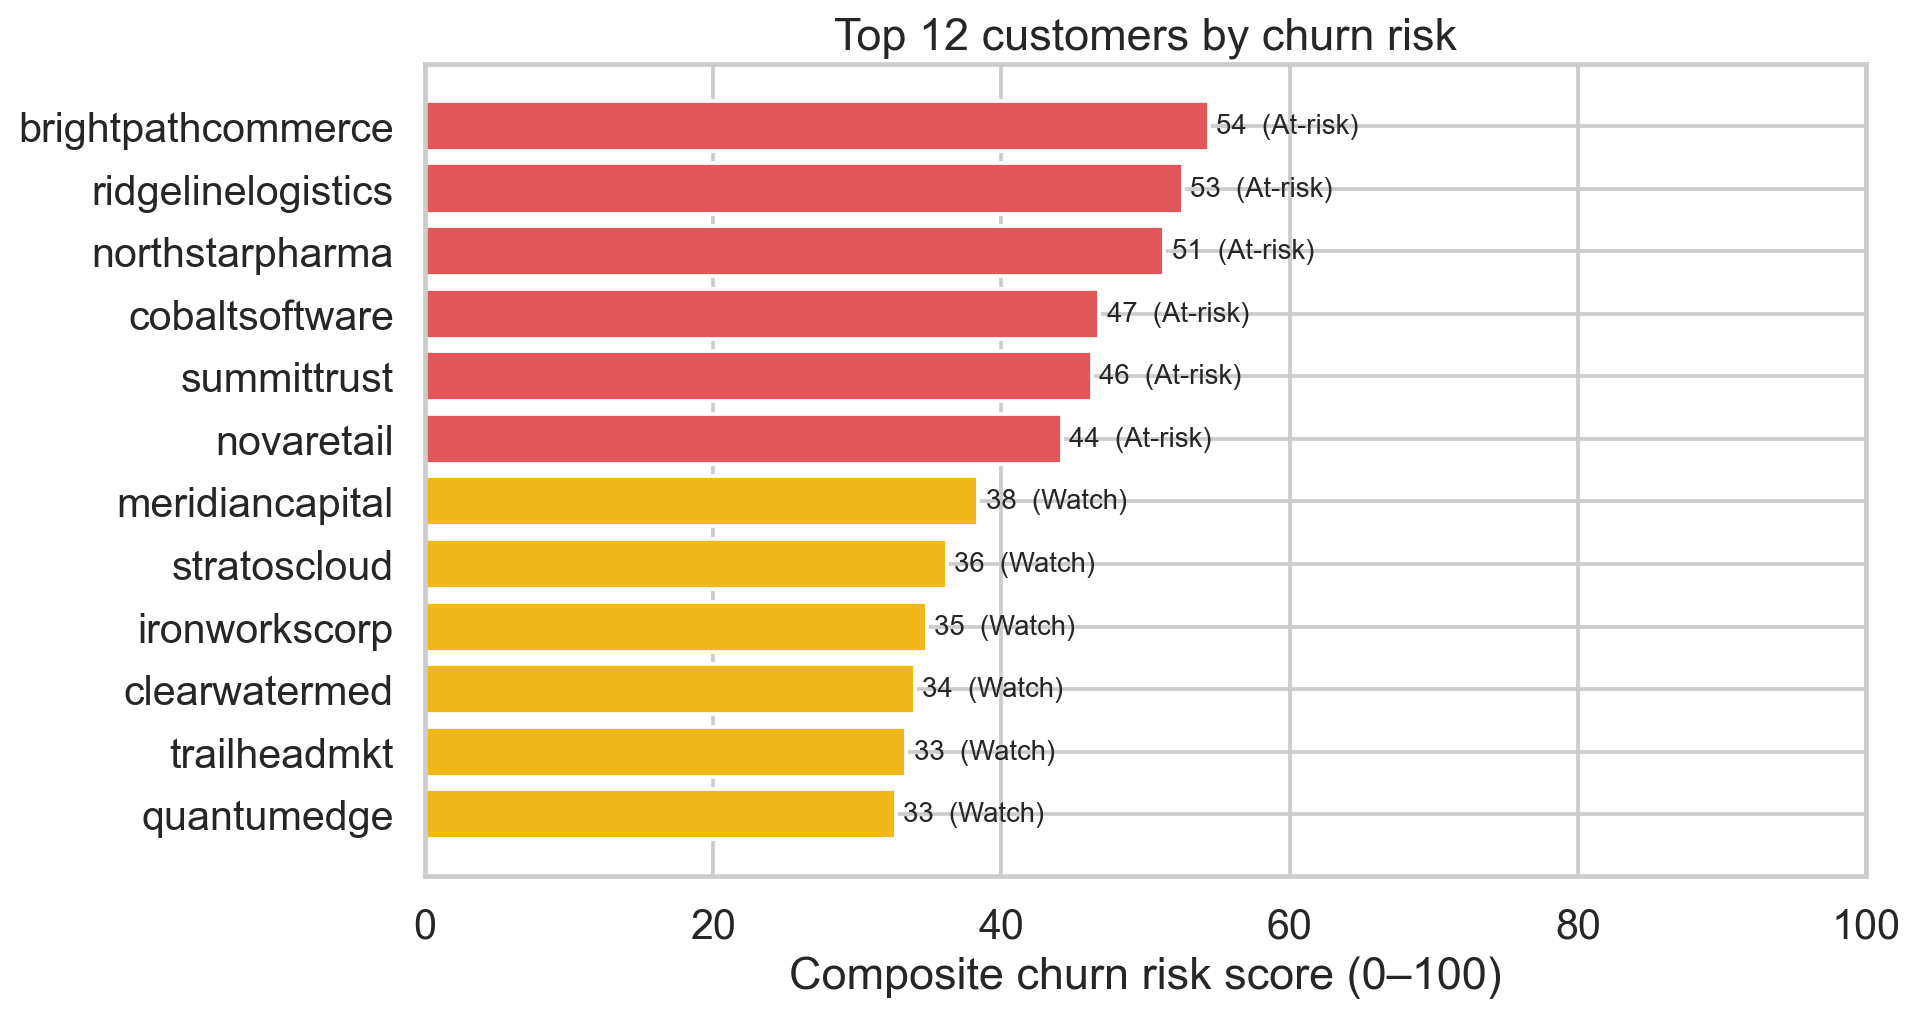

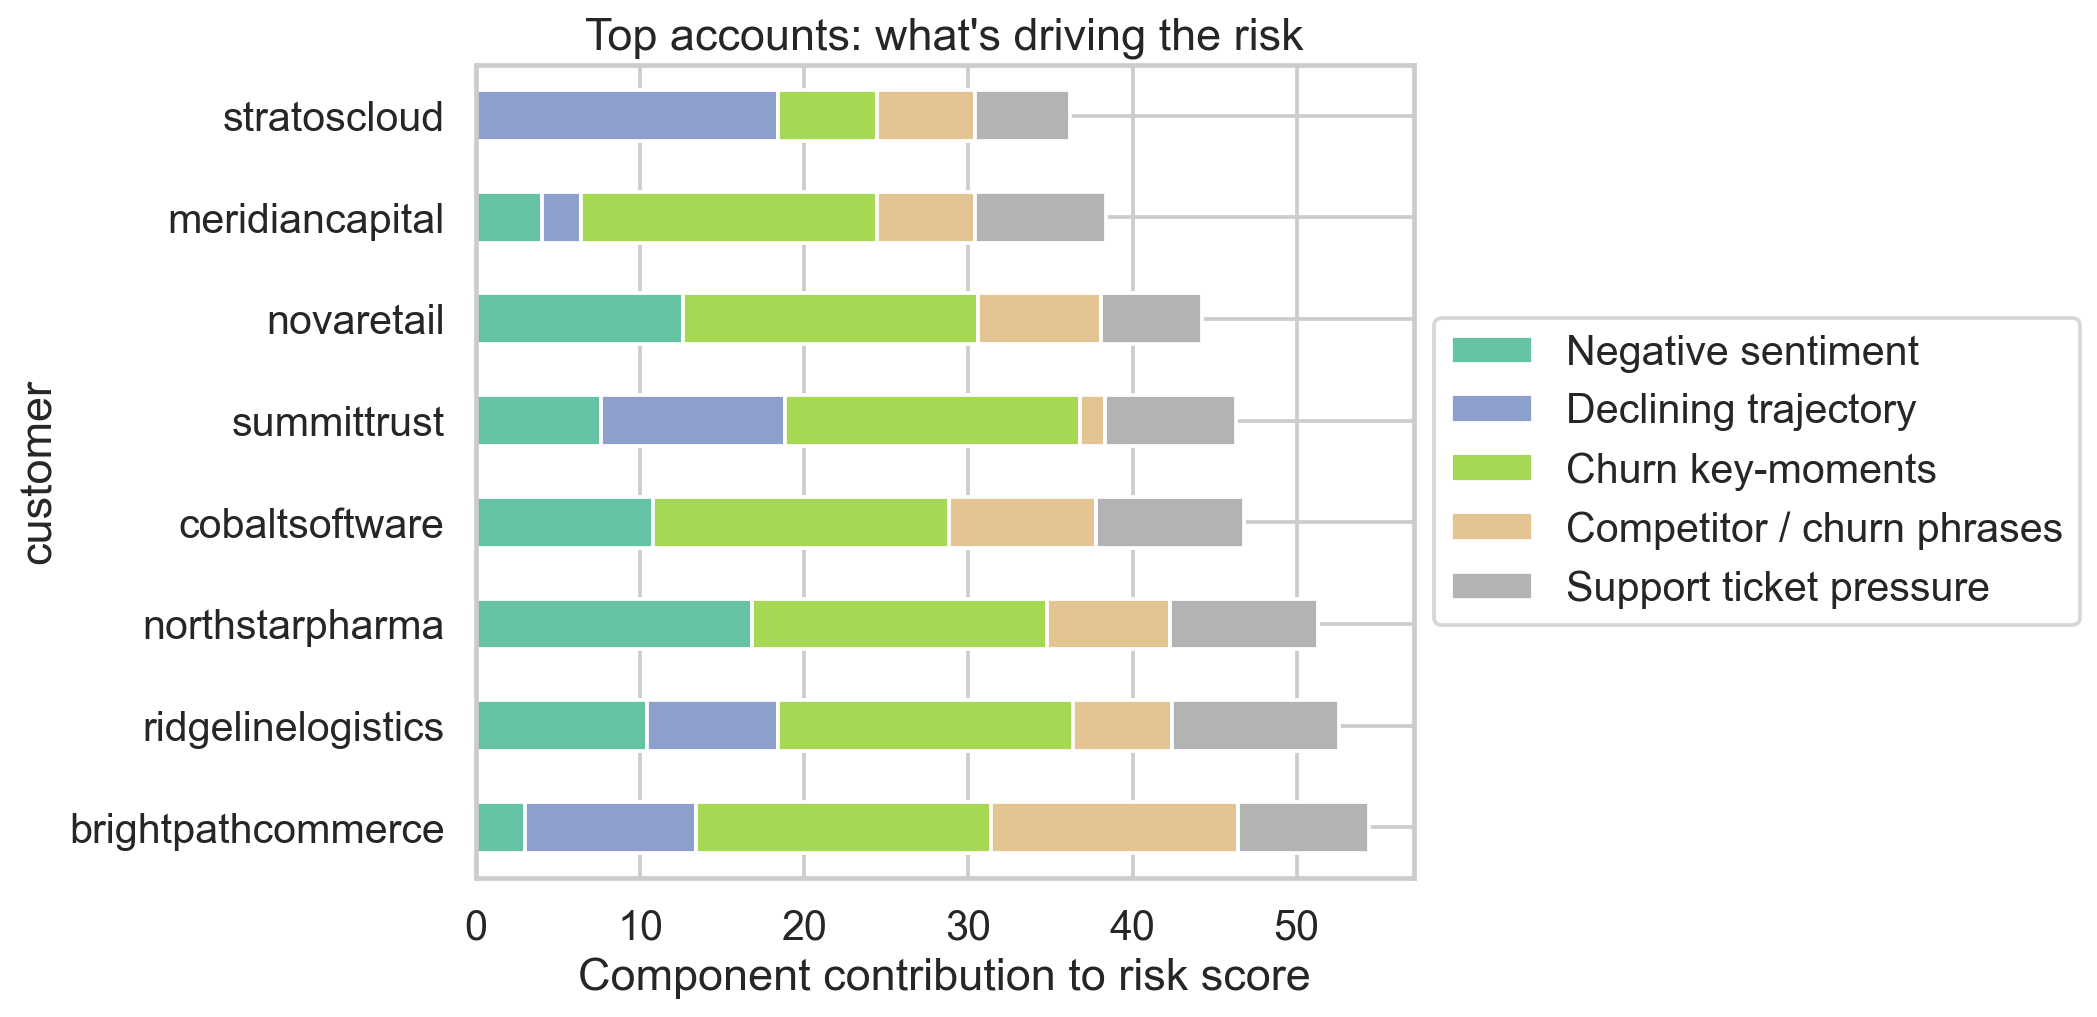

In [15]:
display(Image(filename=str(FIG / "06_churn_risk_top12.png")))
display(Image(filename=str(FIG / "07_churn_risk_components.png")))


### Reading the leaderboard

- **Brightpath Commerce (54, At-risk)** — driven heavily by competitor mentions (10!) and
  negative trajectory. We saw the journey chart above; this is the same story scored.
- **Ridgeline Logistics (53, At-risk)** — 2 support tickets + 3 churn key-moments + declining
  trajectory. The Detect latency issues are cascading.
- **Northstar Pharma (51, At-risk)** — the lowest-sentiment customer (2.10) but only one
  call. *Caveat*: with n=1, the score is fragile. We'd want more touch-points before action.
- The 6 At-risk + 6 Watch accounts represent **~38% of our external customer base** —
  any product launch / change-management cycle should consider them first.

### What's missing from this score

Honest about limitations:

- **No usage/product telemetry.** A churn score from calls alone misses the silent
  customer who's quietly using less. Combine with product analytics for the real signal.
- **Doesn't weight call recency.** A negative call from 6 months ago shouldn't count
  the same as last week's. With more data and timestamps spanning >1 quarter, we'd
  exponentially decay older calls.
- **English-only sentiment.** Fine for this dataset; not for global rollout.

## 6. Bonus 3 — Speaker dynamics (AM coaching signal)

### The hypothesis

In sales/CS, **listen-to-talk ratio is one of the most reliable predictors of call
quality**. Top reps talk less than 50% of the time and ask more questions. We can derive
this from speaker-segmented transcripts.

In [16]:
sd = pd.read_csv(TBL / "speaker_dynamics.csv")
print("Mean talk-time and question rates by call type:")
print(sd.groupby("call_type")[[
    "internal_talk_pct","external_talk_pct",
    "internal_question_ratio","external_question_ratio",
    "internal_neg_pct","external_neg_pct"
]].mean().round(3).to_string())


Mean talk-time and question rates by call type:
           internal_talk_pct  external_talk_pct  internal_question_ratio  external_question_ratio  internal_neg_pct  external_neg_pct
call_type                                                                                                                            
external               0.568              0.432                    0.240                    0.179             0.043             0.235
internal               1.000              0.000                    0.215                    0.000             0.169             0.000
support                0.583              0.417                    0.300                    0.196             0.081             0.396


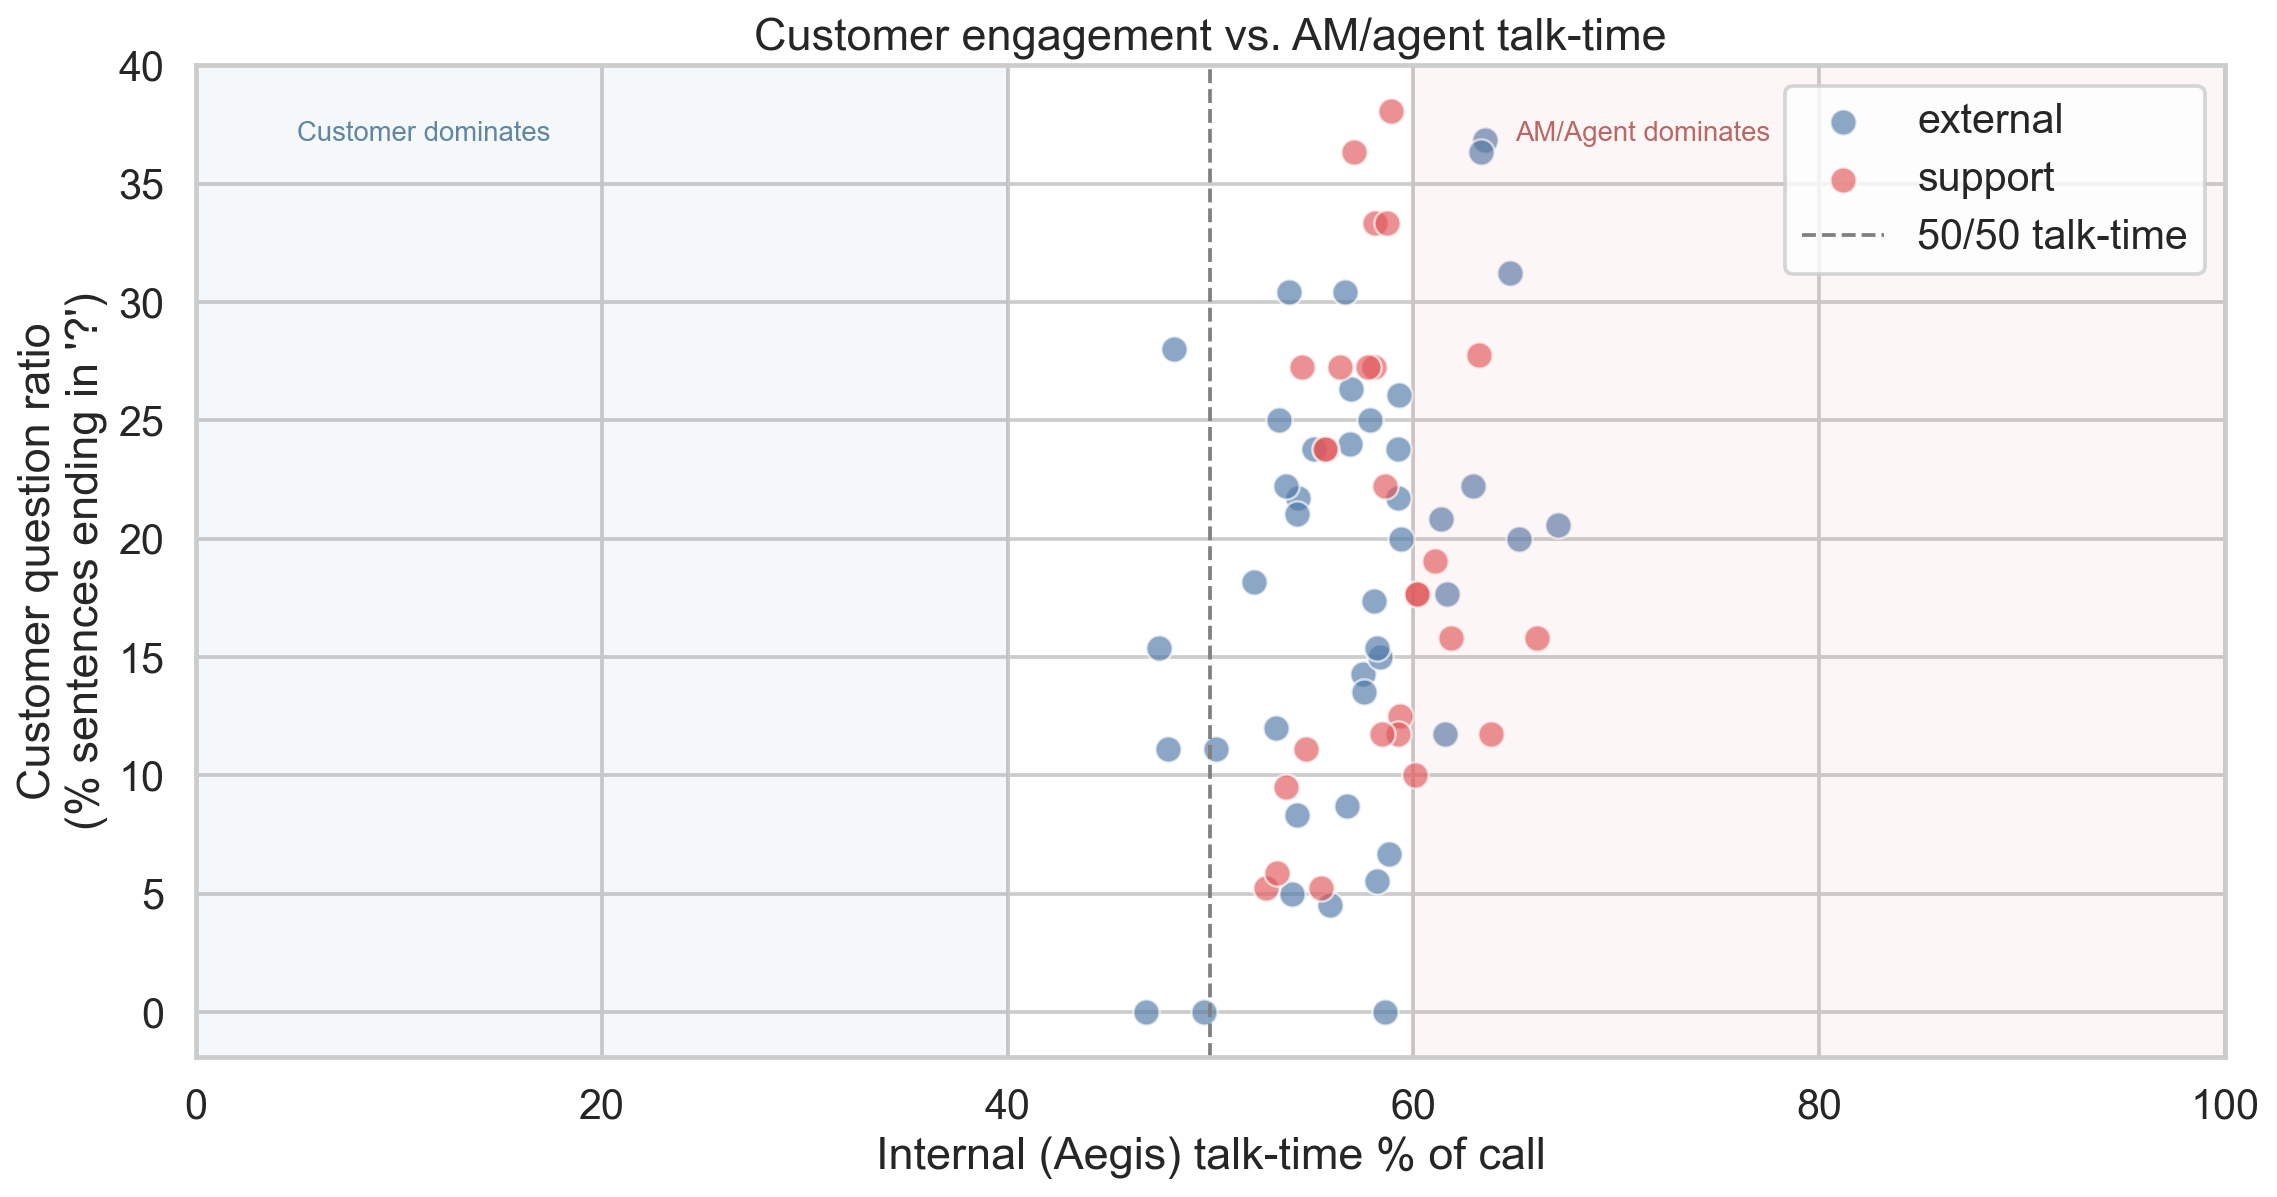

In [17]:
display(Image(filename=str(FIG / "08_speaker_dynamics.png")))

### What this tells us

- **Average external call: internal team (AM) talks 57%.** Slightly above the 50% "good"
  threshold. Most reps are doing fine.
- **Right-quadrant outliers (>60% AM talk)** = calls worth coaching. The pattern in this
  data is that even on high-AM-talk calls, the customer still has a *high* question ratio
  — meaning they're trying to engage but the AM is monologuing. Classic coachable moment.
- **Support calls: agents talk 58%, customers 42%.** Agents resolve issues by explaining;
  customers vent + ask clarifying questions. The 40% negative sentence rate on the customer
  side (vs 6% on the agent side) confirms this is "vent + resolution" pattern.

### What a sales/CS leader would do with this

- Pull the meeting IDs in the **bottom-right quadrant** (high AM talk + high customer
  questions) — those are the coaching candidates.
- Track **average question ratio per AM over time** as a leading indicator of consultative
  selling skill development.
- For support: flag agents whose customers have unusually high negative-sentence rates
  — could mean toughest-cases routing, or could mean rapport problems.

In [18]:
# Top coaching candidates: AM talk > 60% with high customer questions
candidates = sd[
    (sd["call_type"].isin(["external","support"])) &
    (sd["internal_talk_pct"] > 0.60) &
    (sd["external_question_ratio"] > 0.20)
].sort_values("internal_talk_pct", ascending=False)
print("Calls flagged for AM/agent coaching review:\n")
print(candidates[["meeting_id","call_type","customer","internal_talk_pct","external_question_ratio"]].to_string(index=False))


Calls flagged for AM/agent coaching review:

              meeting_id call_type           customer  internal_talk_pct  external_question_ratio
01KQ41FB5CCFD9EA583FB020  external     harborviewbank           0.671175                 0.205882
01KQAFB8DBF6E1E2FDEF0B75  external     maplewoodgoods           0.647729                 0.312500
01KQ1DC6CA536DE1B31ED8F5  external     atlasprecision           0.635432                 0.368421
01KQ77F2867FC54E13A8C495  external brightpathcommerce           0.633351                 0.363636
01KQ56D878454E5783DC6D94   support       stratoscloud           0.632226                 0.277778
01KQ5AFAE8264DDC0ED2AE7F  external    crestlinewealth           0.629342                 0.222222
01KQ54917E3931712516916D  external     nimbusplatform           0.613470                 0.208333


## 7. Additional insight ideas (not implemented; described for the panel)

### A. Action-item accountability tracker
Each `summary.json` ships with `actionItems` — a flat list like
`"Megan Lawson: Draft updated customer communication..."`. Parse those into
`(owner, verb, due_date)` triples. Output a per-person open-action list, and detect
**recurring owners** ("Megan owns 8 of the last 12 incident-comms tasks").

**Who it's for**: directors who want load-balancing data. **Why it's hard to fake**:
the parsing has to be robust to phrasing variation; a small Claude pass with structured
output would be most reliable.

### B. Product-feature → call-type heatmap
Resolve product names (Detect, Comply, Protect, LogVault, Identity) against call topics
and sentiment. Output: "Detect drives 90% of our negative customer calls; Comply drives 80%
of our positive ones." That's a roadmap-prioritisation insight that can be pulled in 30
seconds from an aggregated table.

**Who it's for**: product leadership. **Why valuable**: ties qualitative signal directly
to product surface area, which is a conversation product/eng leaders already have but
without this data.

### C. Internal-to-external response time signal
For accounts where we see an internal call discussing a customer (e.g., "Detect Outage —
Customer Impact Assessment") *then* an external call with that customer, measure the lag
and sentiment delta. Hypothesis: faster internal-to-external follow-up correlates with
better sentiment outcomes on the customer call.

**Who it's for**: COO / VP CS. **Why valuable**: gives a quantitative answer to
"how fast must we respond to incidents?" — a question that's usually answered by gut.

### D. Cross-customer issue clustering (early-warning)
When 3+ different customers raise variants of the same technical issue (e.g., "Detect
alerts not firing", "Detect alert delays", "Detect data gaps") within a short window,
flag it as a **systemic issue**, not three independent tickets. Implement via embedding
the per-call complaint text and running near-duplicate detection.

**Who it's for**: engineering on-call lead. **Why valuable**: faster identification of
patterns currently buried in ticket triage.

## Appendix — running the pipeline

```bash
cd solution/
source .venv/bin/activate          # uses requirements.txt
python -m src.run_pipeline         # ~30 seconds, deterministic
jupyter notebook notebook.ipynb    # open this notebook

# Optional: nicer cluster labels via Claude
export ANTHROPIC_API_KEY=...
python -m src.run_pipeline         # re-runs with LLM cluster naming
```

### Repository layout

```
solution/
├── src/                       # all pipeline code (importable, no notebook deps)
│   ├── ingest.py              # JSON dirs → meetings + sentences DataFrames
│   ├── topics.py              # embeddings + KMeans + TF-IDF labels + LLM naming
│   ├── sentiment.py           # VADER scoring + per-call rollup
│   ├── insights.py            # journey, churn risk, speaker dynamics
│   ├── figures.py             # all matplotlib figures
│   ├── llm.py                 # Anthropic SDK wrapper with on-disk cache
│   └── run_pipeline.py        # end-to-end runner
├── data/                      # parquet outputs (gitignored)
├── outputs/
│   ├── figures/*.png          # presentation-ready charts
│   └── tables/*.csv           # supporting tables (churn risk, journey, etc.)
├── slides/                    # the presentation deliverable
├── notebook.ipynb             # this notebook
└── README.md
```